In [276]:
# Load Estimator Functions

import numpy as np
import matplotlib.pyplot as plt

from loader import load_estimator_functions
from parallel_runner import run_functions_parallel
from estimator4 import estimate_latent_and_input

try:
    functions = load_estimator_functions(r"C:\Users\Jack_\Documents\IIA Work\Engineering\IIA\IIA project work\GG4\codebase\GG4 clean")
    print(functions)
except:
    print("No student estimators found. You are in result-only mode.")
    print('foo')
    functions = {}

No student estimators found. You are in result-only mode.
foo


In [277]:
i = 1
for key in functions.keys():
    print(f"{i}: {key}")
    i += 1

In [278]:
import importlib.util, traceback

spec = importlib.util.spec_from_file_location(
    "test",
    r"C:\Users\Jack_\Documents\IIA Work\Engineering\IIA\IIA project work\GG4\codebase\GG4_clean\estimator1.py"
)
module = importlib.util.module_from_spec(spec)
try:
    spec.loader.exec_module(module)
    print("loaded ok")
except Exception:
    traceback.print_exc()

loaded ok


# Real Tests

In [279]:
import importlib
import SimulationIllustrationFuncs
importlib.reload(SimulationIllustrationFuncs)
from SimulationIllustrationFuncs import simulate, simulate_from_latents, fit_transform_latents, plot_input_latent_observation, plot_input_latent_comparison_interactive

%matplotlib widget

## Sparse Impulse Input

### Case 1

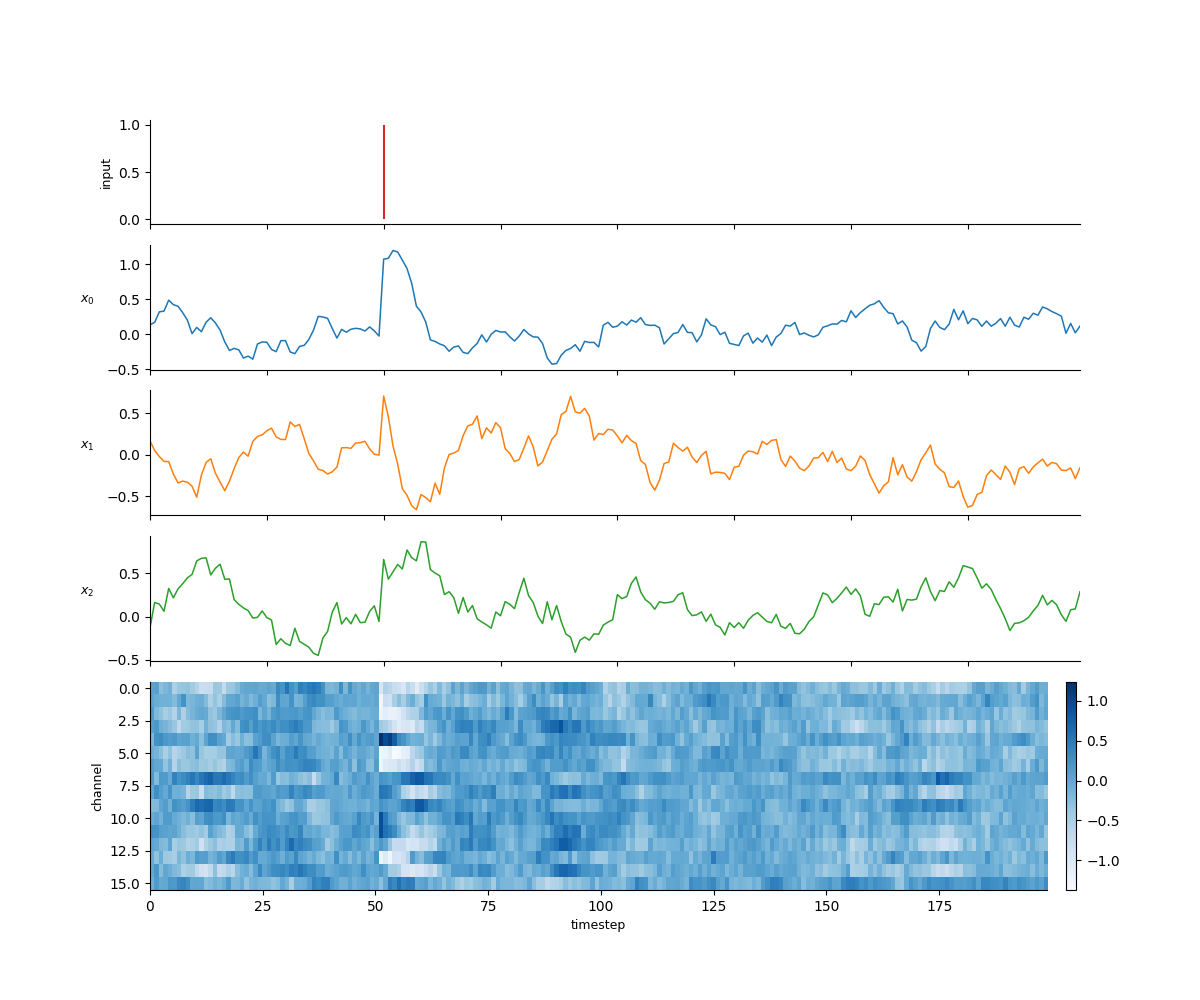

In [280]:
A = np.array([[0.9, 0.1, 0],
              [-0.2, 0.8, 0],
              [0.1, -0.1, 0.8]])

B = np.array([[1], 
              [0.6], 
              [0.8]])

C = np.random.normal(0, 1, (16, 3))
C /= np.linalg.norm(C, axis=1, keepdims=True)


inputs = np.zeros((200, 1))
inputs[50] = 1

x_noise = np.random.normal(0, 0.1, (200, 3))
y_noise = np.random.normal(0, 0.1, (200, 16))

states, observations = simulate(A, B, C, inputs, x_noise, y_noise)

plot_input_latent_observation(inputs, states, observations)
plt.show()

  EM iter   1  |  LL = -2092.4553  |  u_nnz = 197
  EM iter   2  |  LL = -2148.0088  |  u_nnz = 199
  EM iter   3  |  LL = -2192.3411  |  u_nnz = 199
  EM iter   4  |  LL = -2208.1052  |  u_nnz = 199
  EM iter   5  |  LL = -2212.0452  |  u_nnz = 199
  EM iter   6  |  LL = -2212.9293  |  u_nnz = 199
  EM iter   7  |  LL = -2213.1227  |  u_nnz = 199
  Converged at iter 7 (Δ=8.74e-05)


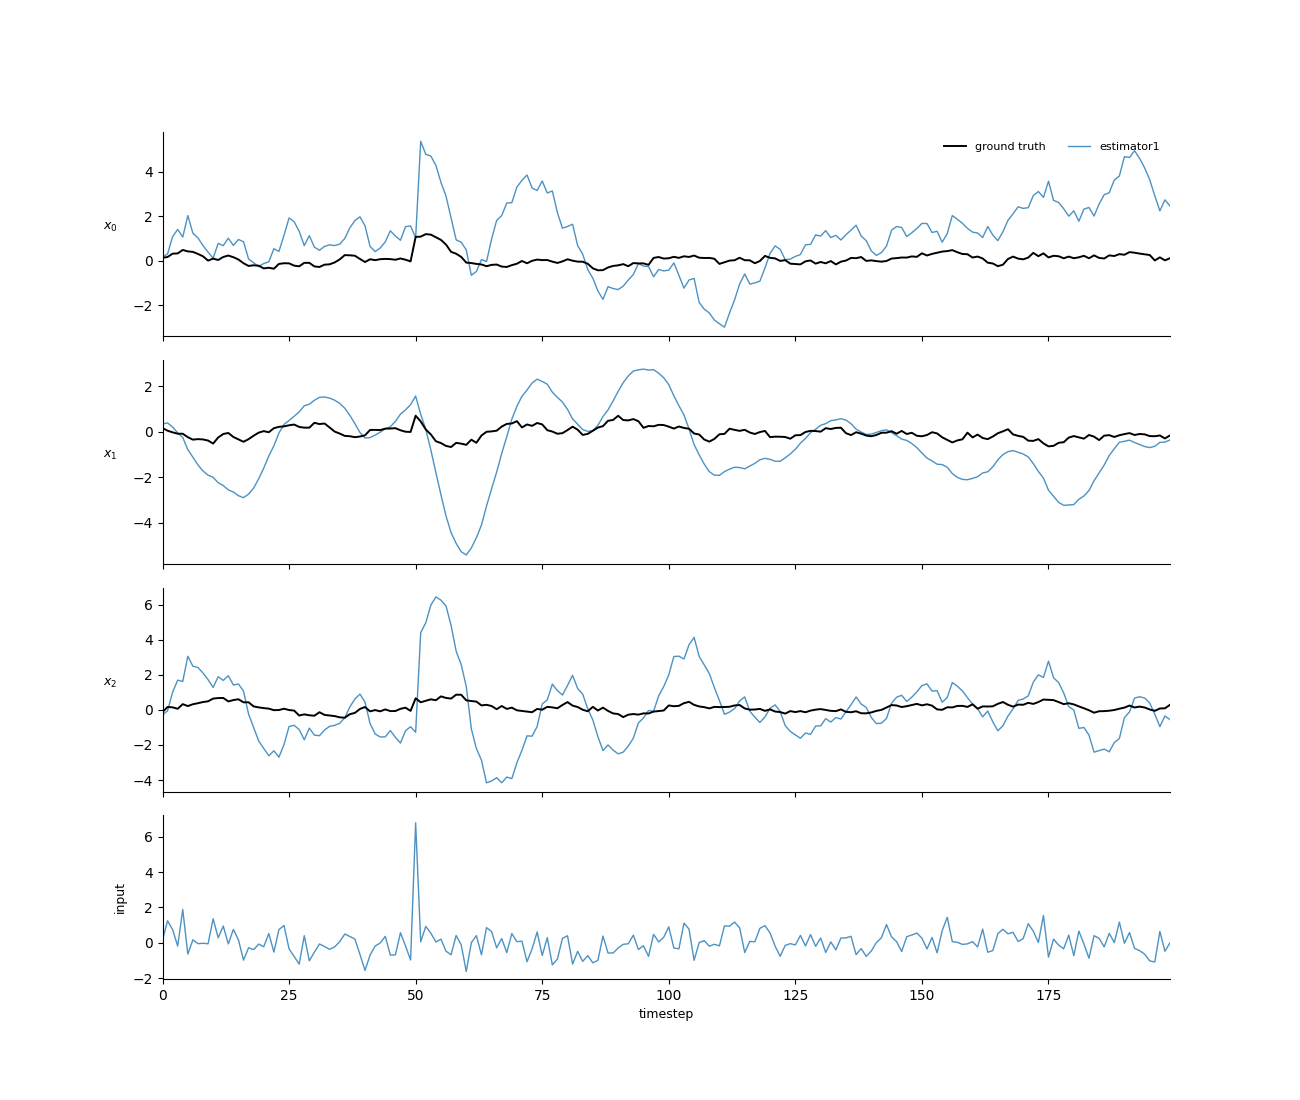

In [281]:
# try:
#     np.load("MethodResults/SparseImpulseInput_Case1.npz")
# except FileNotFoundError:
#     results = run_functions_parallel(
#         functions,=
#         input_dim=1,
#         max_workers="auto",
#         native_threads_per_worker=1,
#         backend="thread",
#         print_shapes=False,
#     )
#     np.savez("MethodResults/SparseImpulseInput_Case1.npz", **results)



# results = run_functions_parallel(
#         functions,
#         observations,
#         latent_dim=3,
#         input_dim=1,
#         max_workers="auto",
#         native_threads_per_worker=1,
#         backend="thread",
#         print_shapes=False,
#     )

latent_states, inputs = estimate_latent_and_input(observations, LatentDim=3, InputDim=1)
results = {
    "estimator1": {
        "latent_states": latent_states,
        "inputs": inputs,
    }
}

plot_input_latent_comparison_interactive(inputs, states, results, align_inputs=False, align_latents=True, active={})
plt.show()

### Case 2 - null-space injection

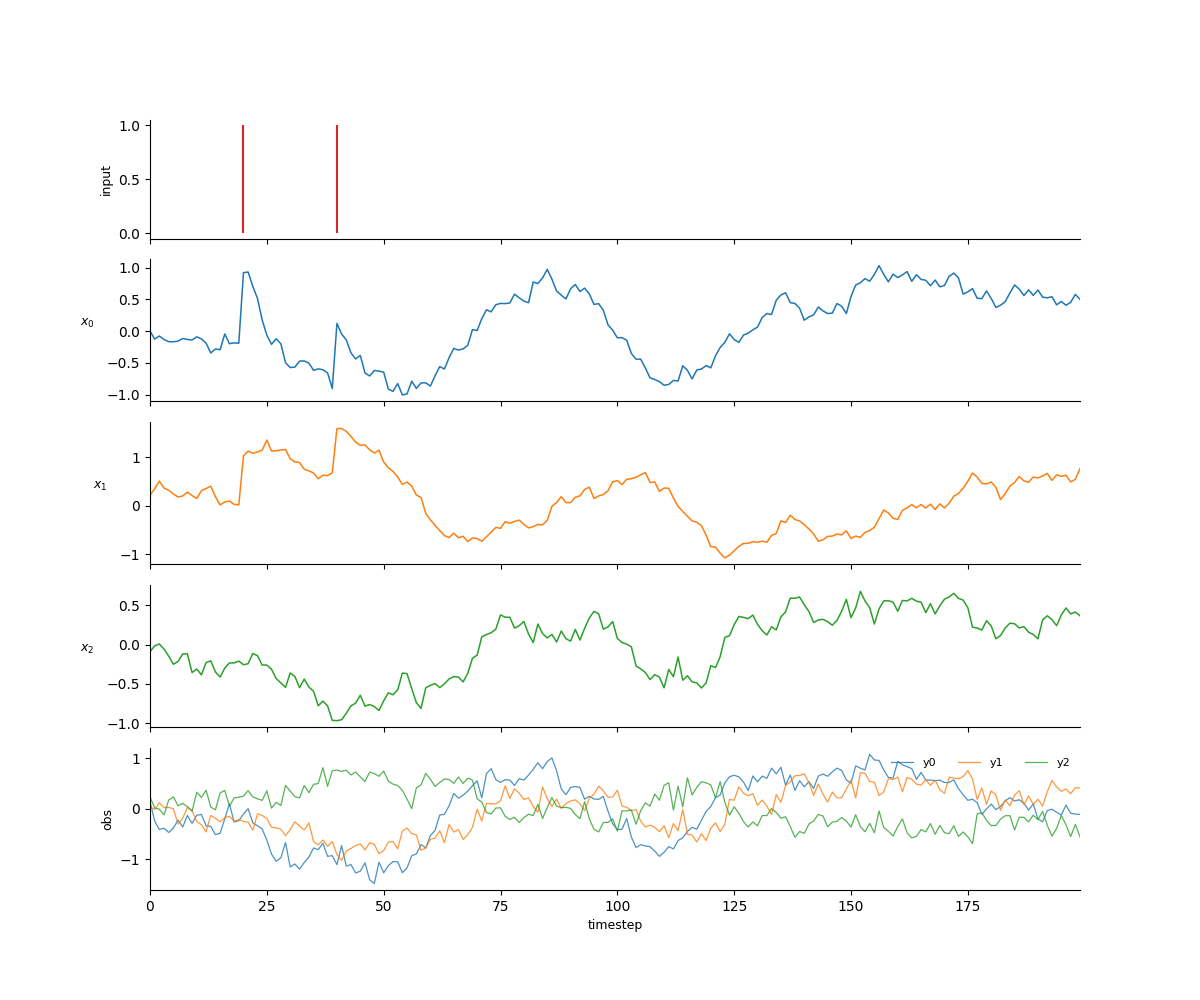

In [282]:
angle = 5 / 180 * np.pi
A = np.array([[np.cos(angle) * 0.98, -np.sin(angle) * 0.98, 0],
              [np.sin(angle) * 0.98, np.cos(angle) * 0.98, 0],
              [0.1, -0.1, 0.8]])

B = np.array([[1], 
              [1], 
              [0]])

C = np.array([[1, -1, 0], 
              [0, 0, 1], 
              [0.1, -0.098, -1]])
C /= np.linalg.norm(C, axis=1, keepdims=True)


inputs = np.zeros((200, 1))
inputs[20] = 1
inputs[40] = 1

x_noise = np.random.normal(0, 0.1, (200, 3))
y_noise = np.random.normal(0, 0.1, (200, 3))

states, observations = simulate(A, B, C, inputs, x_noise, y_noise)

plot_input_latent_observation(inputs, states, observations)
plt.show()

  EM iter   1  |  LL = -474.3391  |  u_nnz = 197
  EM iter   2  |  LL = -536.4265  |  u_nnz = 199
  EM iter   3  |  LL = -584.2989  |  u_nnz = 199
  EM iter   4  |  LL = -600.9953  |  u_nnz = 197
  EM iter   5  |  LL = -605.0147  |  u_nnz = 197
  EM iter   6  |  LL = -605.8801  |  u_nnz = 196
  EM iter   7  |  LL = -606.0616  |  u_nnz = 196
  EM iter   8  |  LL = -606.0995  |  u_nnz = 196
  Converged at iter 8 (Δ=6.25e-05)


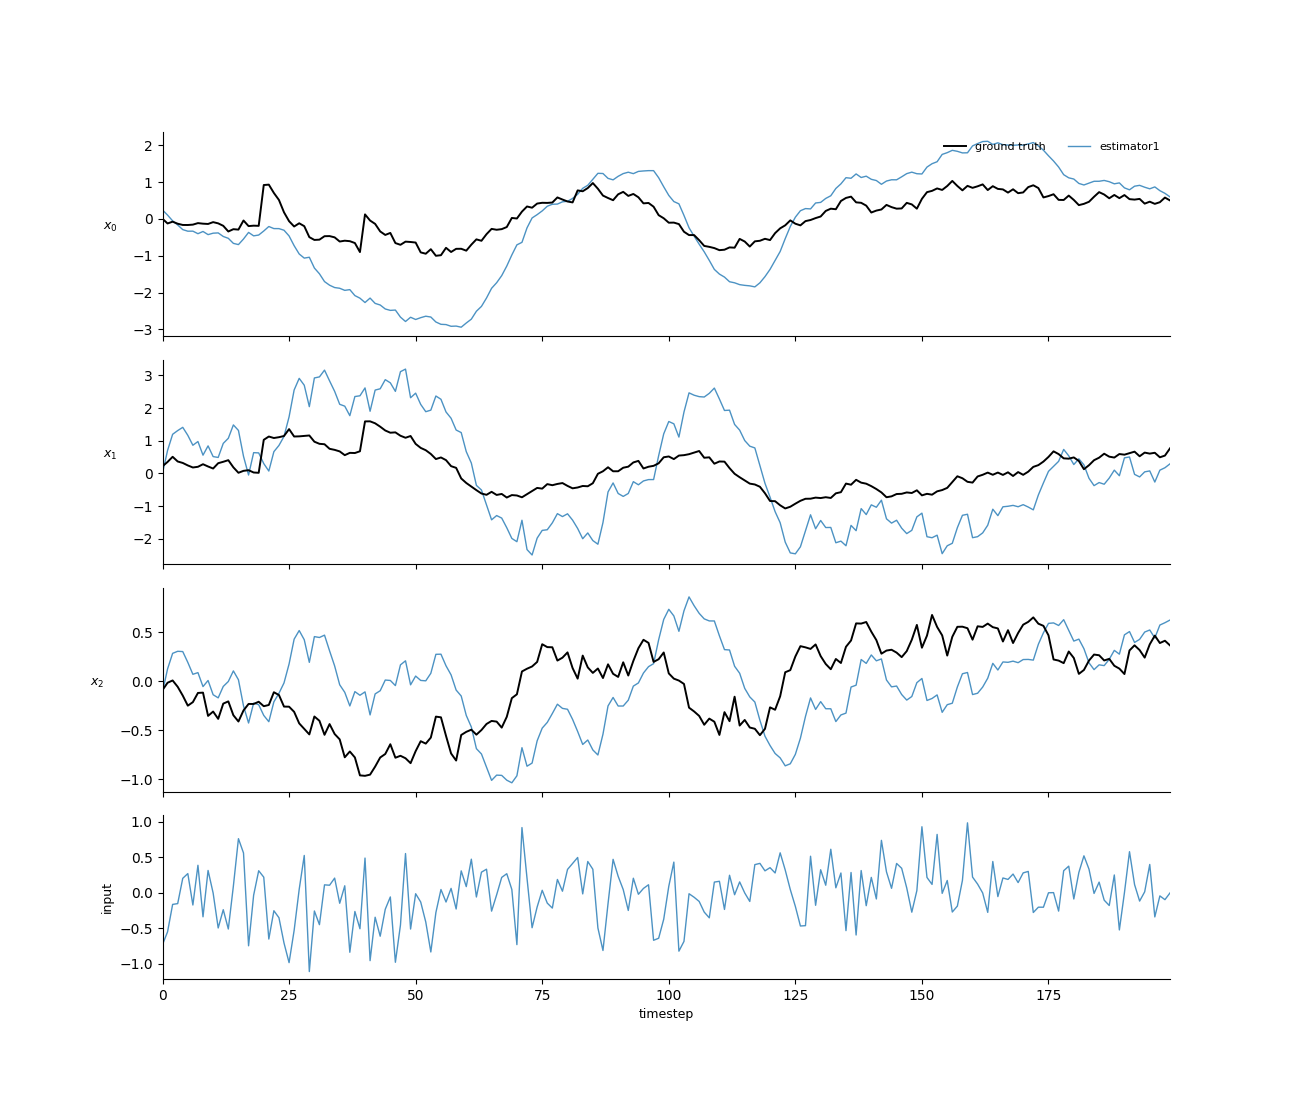

In [283]:
# try:
#     np.load("MethodResults/SparseImpulseInput_Case2.npz")
# except FileNotFoundError:
#     results = run_functions_parallel(
#         functions,
#         observations,
#         latent_dim=3,
#         input_dim=1,
#         max_workers="auto",
#         native_threads_per_worker=1,
#         backend="thread",
#         print_shapes=False,
#     )
#     np.savez("MethodResults/SparseImpulseInput_Case2.npz", **results)


latent_states, inputs = estimate_latent_and_input(observations, LatentDim=3, InputDim=1)
results = {
    "estimator1": {
        "latent_states": latent_states,
        "inputs": inputs,
    }
}

plot_input_latent_comparison_interactive(inputs, states, results, align_inputs=False, align_latents=True, active={})
plt.show()

### Case 3 - null-space injection

A eigenvalues (magnitude): [0.8  0.97 0.95]
A eigenvalues (angle deg): [0. 0. 0.]
Spectral radius: 0.9700


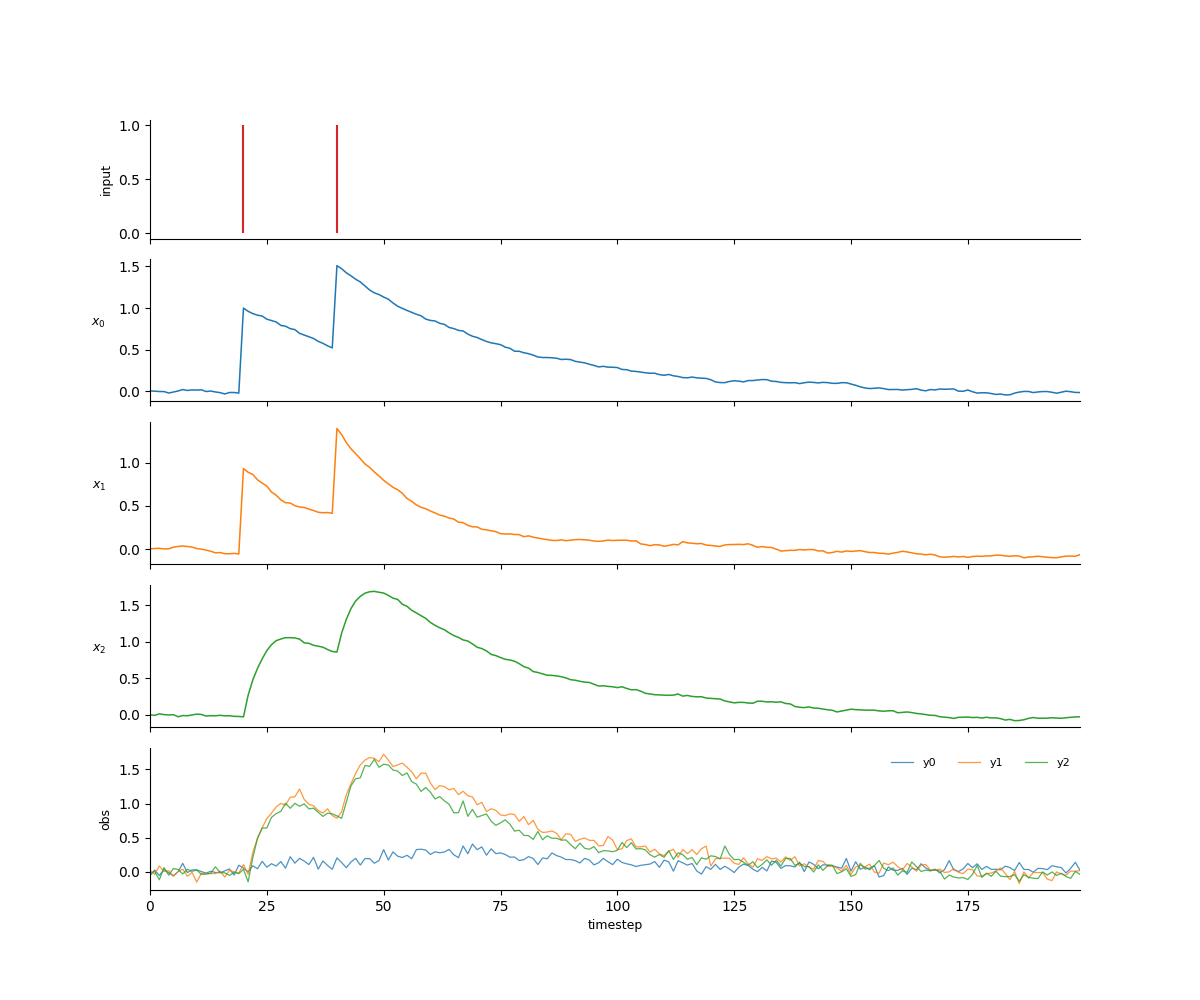

In [284]:
A = np.array([[0.97, 0, 0],
              [0, 0.95, 0],
              [0.2, 0.1, 0.8]])

B = np.array([[1], 
              [1], 
              [0]])

C = np.array([[1, -1, 0], 
              [0.1, -0.1, 0.5], 
              [-0.1, 0.09, 0.5]])
C /= np.linalg.norm(C, axis=1, keepdims=True)


inputs = np.zeros((200, 1))
inputs[20] = 1
inputs[40] = 1

x_noise = np.random.normal(0, 0.01, (200, 3))
y_noise = np.random.normal(0, 0.05, (200, 3))

states, observations = simulate(A, B, C, inputs, x_noise, y_noise)
eigs = np.linalg.eigvals(A)
print(f"A eigenvalues (magnitude): {np.abs(eigs)}")
print(f"A eigenvalues (angle deg): {np.angle(eigs, deg=True)}")
print(f"Spectral radius: {np.abs(eigs).max():.4f}")

plot_input_latent_observation(inputs, states, observations)
plt.show()

  EM iter   1  |  LL = -443.2564  |  u_nnz = 194
  EM iter   2  |  LL = -512.4092  |  u_nnz = 196
  EM iter   3  |  LL = -558.5882  |  u_nnz = 199
  EM iter   4  |  LL = -572.2234  |  u_nnz = 199
  EM iter   5  |  LL = -575.0830  |  u_nnz = 198
  EM iter   6  |  LL = -575.6317  |  u_nnz = 198
  EM iter   7  |  LL = -575.7351  |  u_nnz = 198
  EM iter   8  |  LL = -575.7546  |  u_nnz = 198
  Converged at iter 8 (Δ=3.37e-05)


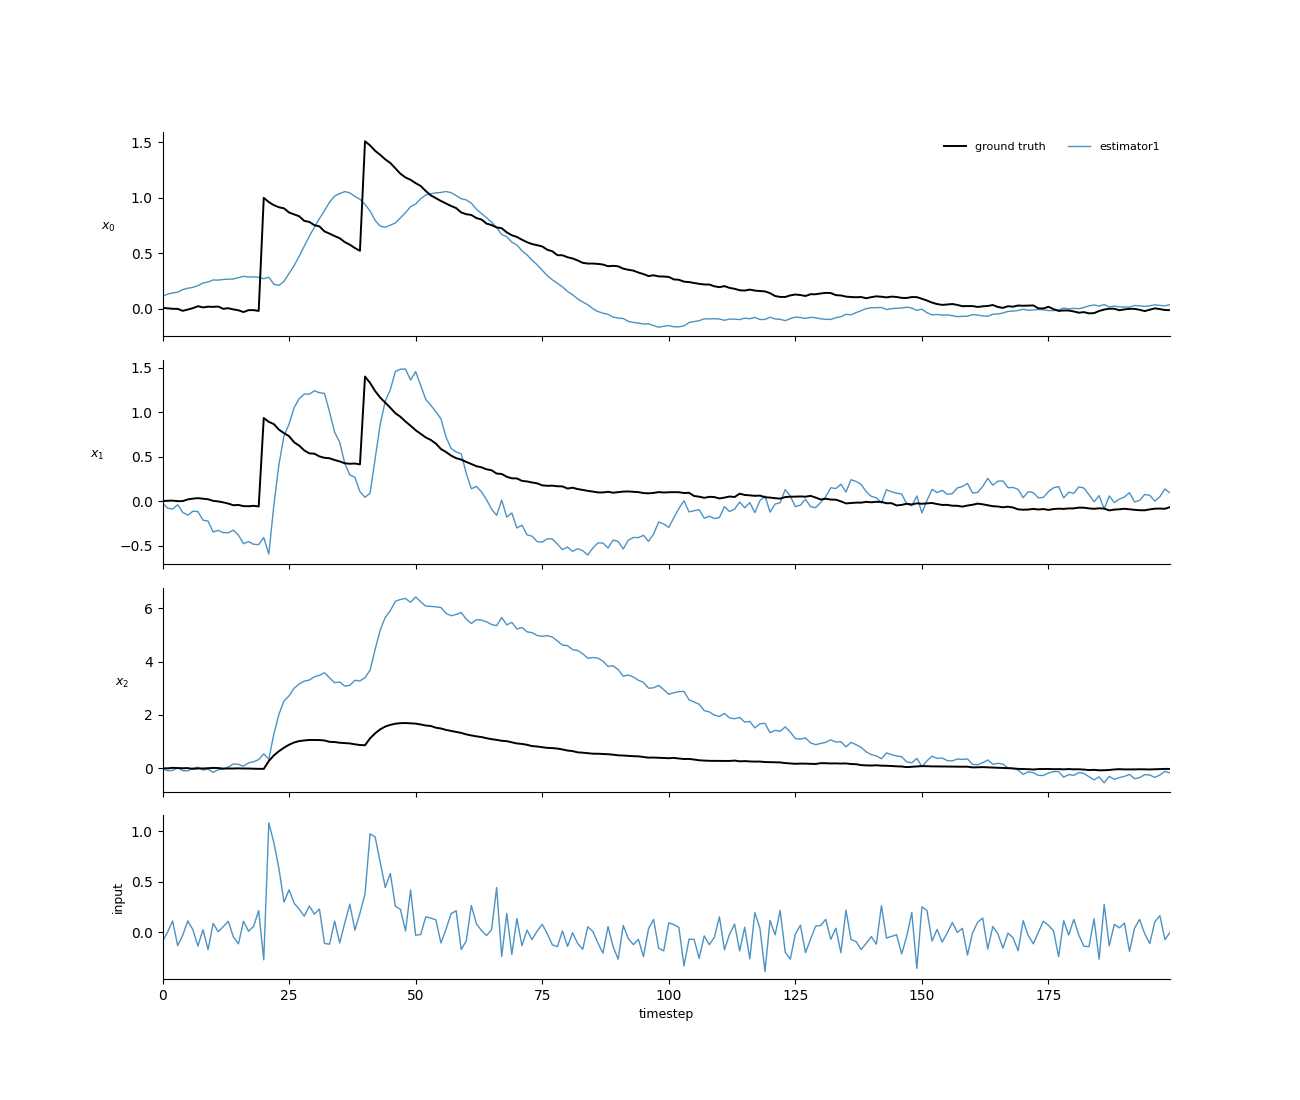

In [285]:
# try:
#     np.load("MethodResults/SparseImpulseInput_Case3.npz")
# except FileNotFoundError:
#     results = run_functions_parallel(
#         functions,
#         observations,
#         latent_dim=3,
#         input_dim=1,
#         max_workers="auto",
#         native_threads_per_worker=1,
#         backend="thread",
#         print_shapes=False,
#     )
#     np.savez("MethodResults/SparseImpulseInput_Case3.npz", **results)



latent_states, inputs = estimate_latent_and_input(observations, LatentDim=3, InputDim=1)
results = {
    "estimator1": {
        "latent_states": latent_states,
        "inputs": inputs,
    }
}


plot_input_latent_comparison_interactive(inputs, states, results, align_inputs=False, align_latents=True, active={})
plt.show()

### Case 4 - ill-conditioned

A eigenvalues (magnitude): [0.9  0.01]
A eigenvalues (angle deg): [0. 0.]
Spectral radius: 0.9000


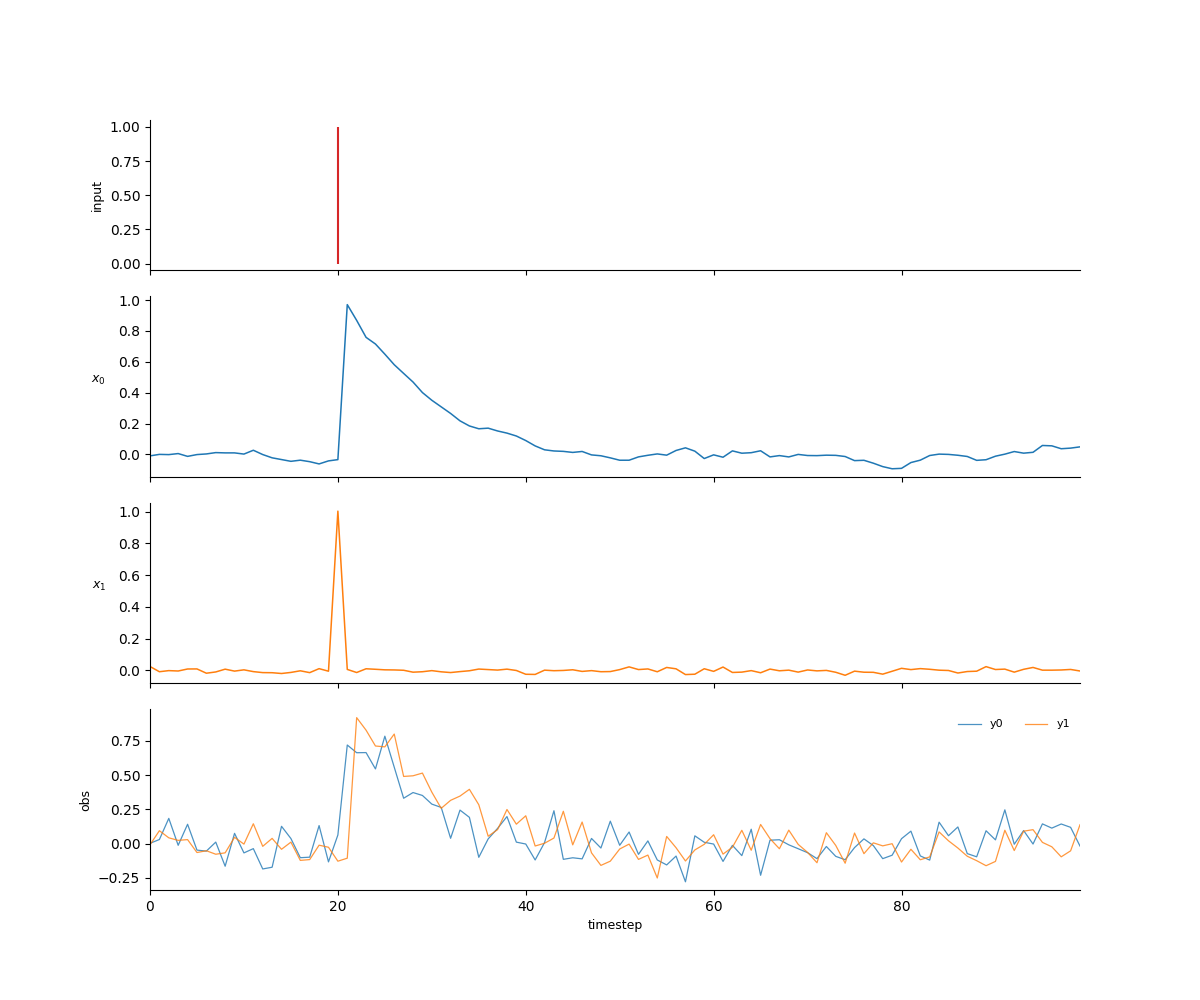

In [286]:
A = np.array([[0.9, 1],
              [0, 0.01]])

B = np.array([[0],
              [1]])

C = np.array([[1.0, 1.0],
              [1.0, 0.0]])
C /= np.linalg.norm(C, axis=1, keepdims=True)

inputs = np.zeros((100, 1))
inputs[20] = 1

x_noise = np.random.normal(0, 0.01, (100, 2))
y_noise = np.random.normal(0, 0.1, (100, 2))

states, observations = simulate(A, B, C, inputs, x_noise, y_noise)

eigs = np.linalg.eigvals(A)
print(f"A eigenvalues (magnitude): {np.abs(eigs)}")
print(f"A eigenvalues (angle deg): {np.angle(eigs, deg=True)}")
print(f"Spectral radius: {np.abs(eigs).max():.4f}")

plot_input_latent_observation(inputs, states, observations)
plt.show()

  EM iter   1  |  LL = -167.2883  |  u_nnz = 98
  EM iter   2  |  LL = -225.7735  |  u_nnz = 99
  EM iter   3  |  LL = -244.0522  |  u_nnz = 97
  EM iter   4  |  LL = -246.1746  |  u_nnz = 96
  EM iter   5  |  LL = -246.3713  |  u_nnz = 97
  EM iter   6  |  LL = -246.3891  |  u_nnz = 97
  Converged at iter 6 (Δ=7.22e-05)


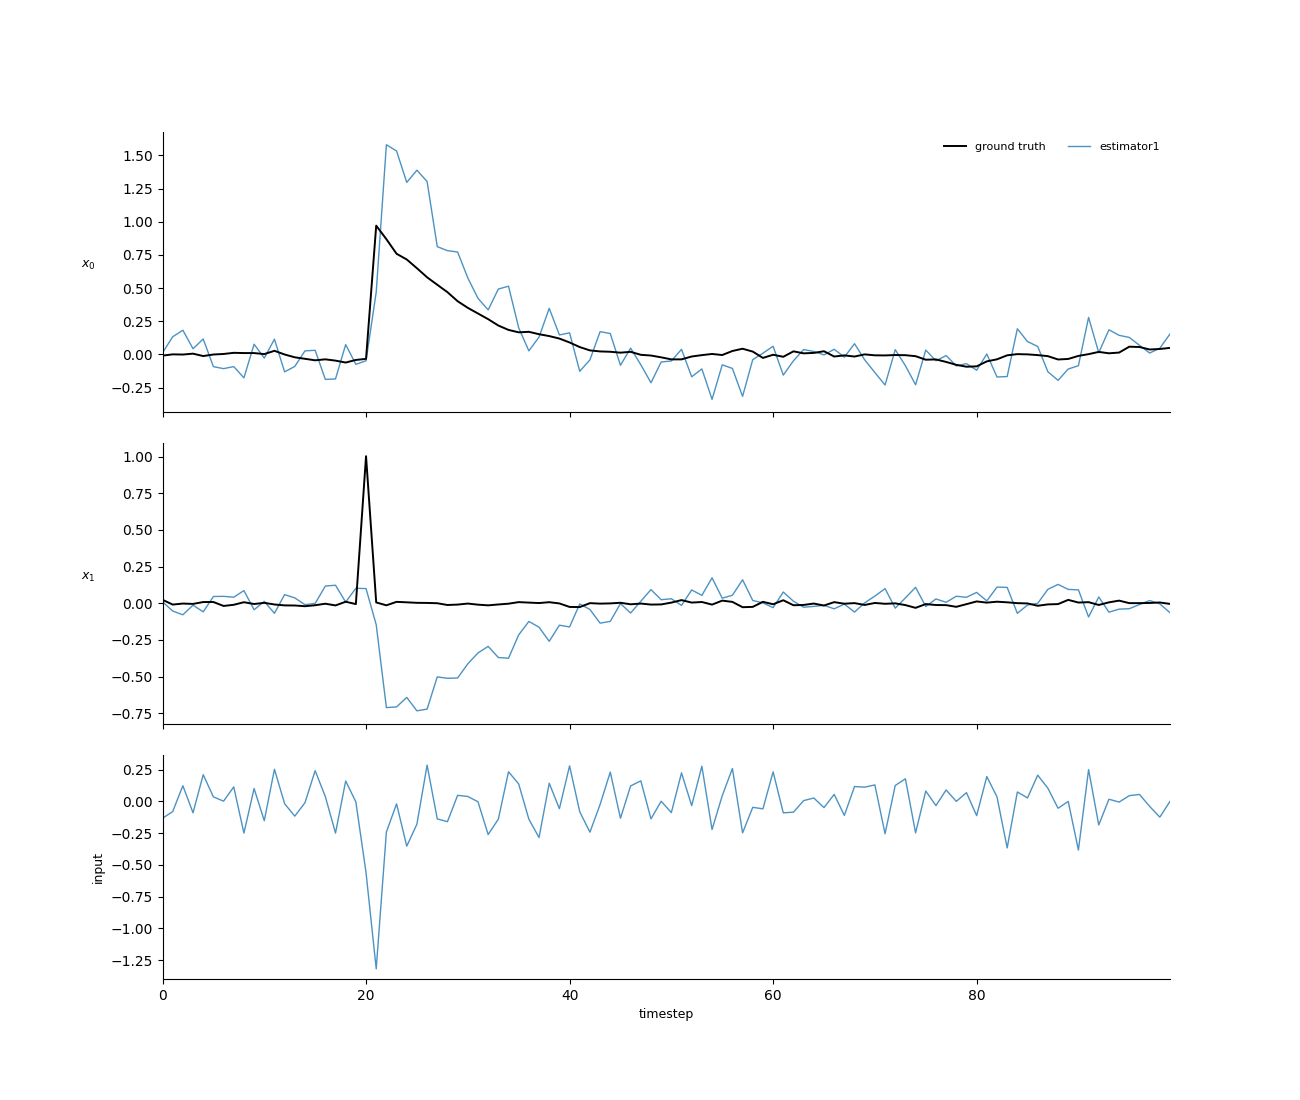

In [287]:
# try:
#     np.load("MethodResults/SparseImpulseInput_Case4.npz")
# except FileNotFoundError:
#     results = run_functions_parallel(
#         functions,
#         observations,
#         latent_dim=2,
#         input_dim=1,
#         max_workers="auto",
#         native_threads_per_worker=1,
#         backend="thread",
#         print_shapes=False,
#     )
#     np.savez("MethodResults/SparseImpulseInput_Case4.npz", **results)

latent_states, inputs = estimate_latent_and_input(observations, LatentDim=3, InputDim=1)
results = {
    "estimator1": {
        "latent_states": latent_states,
        "inputs": inputs,
    }
}

plot_input_latent_comparison_interactive(inputs, states, results, align_inputs=False, align_latents=True, active={})
plt.show()

### Case 5 - ill-conditioned

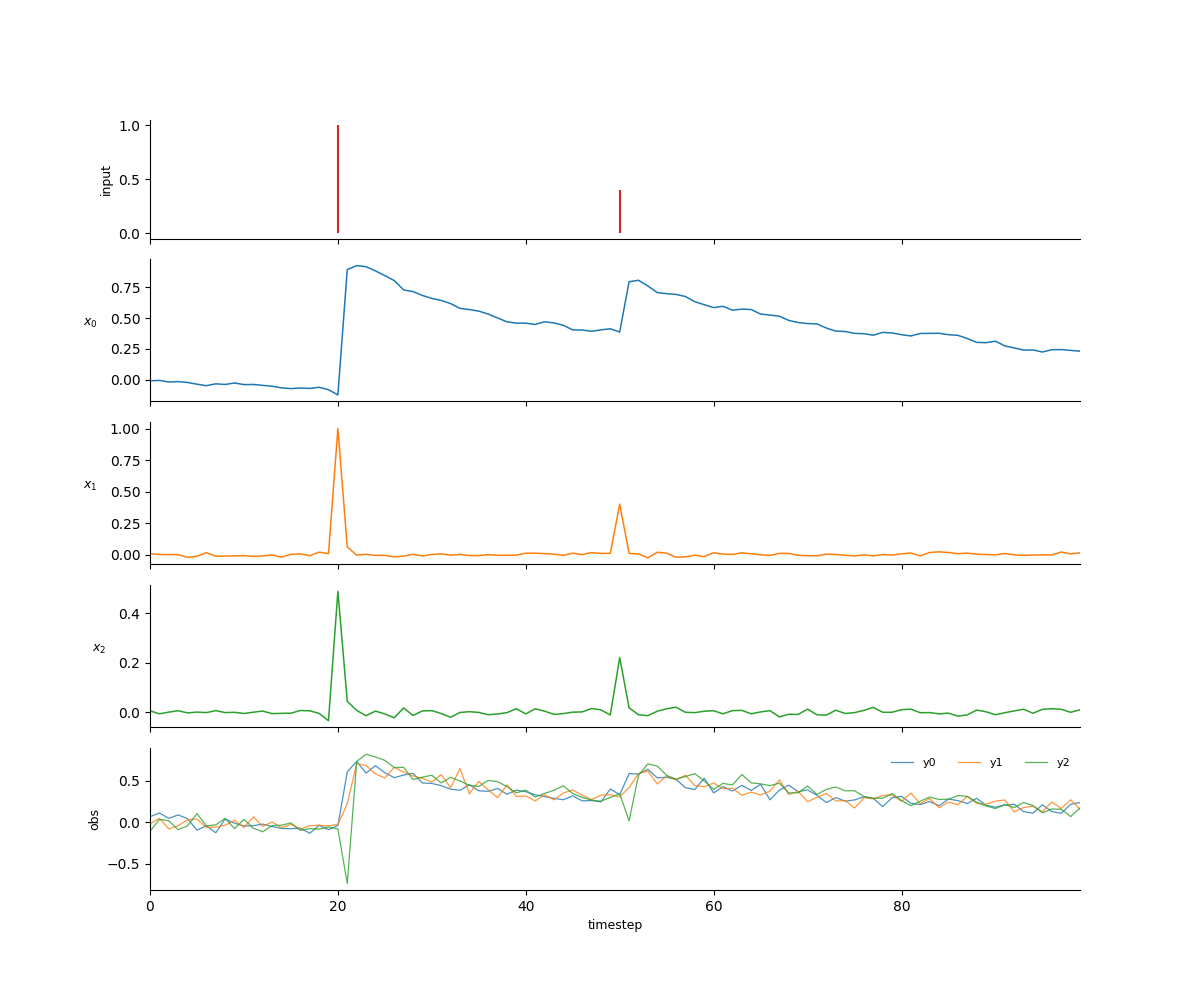

In [288]:
A = np.array([[0.97, 0.5, 1],
              [0, 0.05, 0],
              [0, 0, 0.1]])

B = np.array([[0,],
              [1,],
              [0.5,],])

C = np.array([[1.0, 1.0, 0],
              [1.0, 0, 1.0],
              [1.0, -0.5, -0.5],])
C /= np.linalg.norm(C, axis=1, keepdims=True)

inputs = np.zeros((100, 1))
inputs[20] = 1
inputs[50] = 0.4

x_noise = np.random.normal(0, 0.01, (100, 3))
y_noise = np.random.normal(0, 0.05, (100, 3))
states, observations = simulate(A, B, C, inputs, x_noise, y_noise)

plot_input_latent_observation(inputs, states, observations)
plt.show()

  EM iter   1  |  LL = -211.2908  |  u_nnz = 98
  EM iter   2  |  LL = -254.5408  |  u_nnz = 99
  EM iter   3  |  LL = -278.9893  |  u_nnz = 98
  EM iter   4  |  LL = -284.3645  |  u_nnz = 97
  EM iter   5  |  LL = -285.2054  |  u_nnz = 98
  EM iter   6  |  LL = -285.3285  |  u_nnz = 98
  EM iter   7  |  LL = -285.3464  |  u_nnz = 98
  Converged at iter 7 (Δ=6.25e-05)


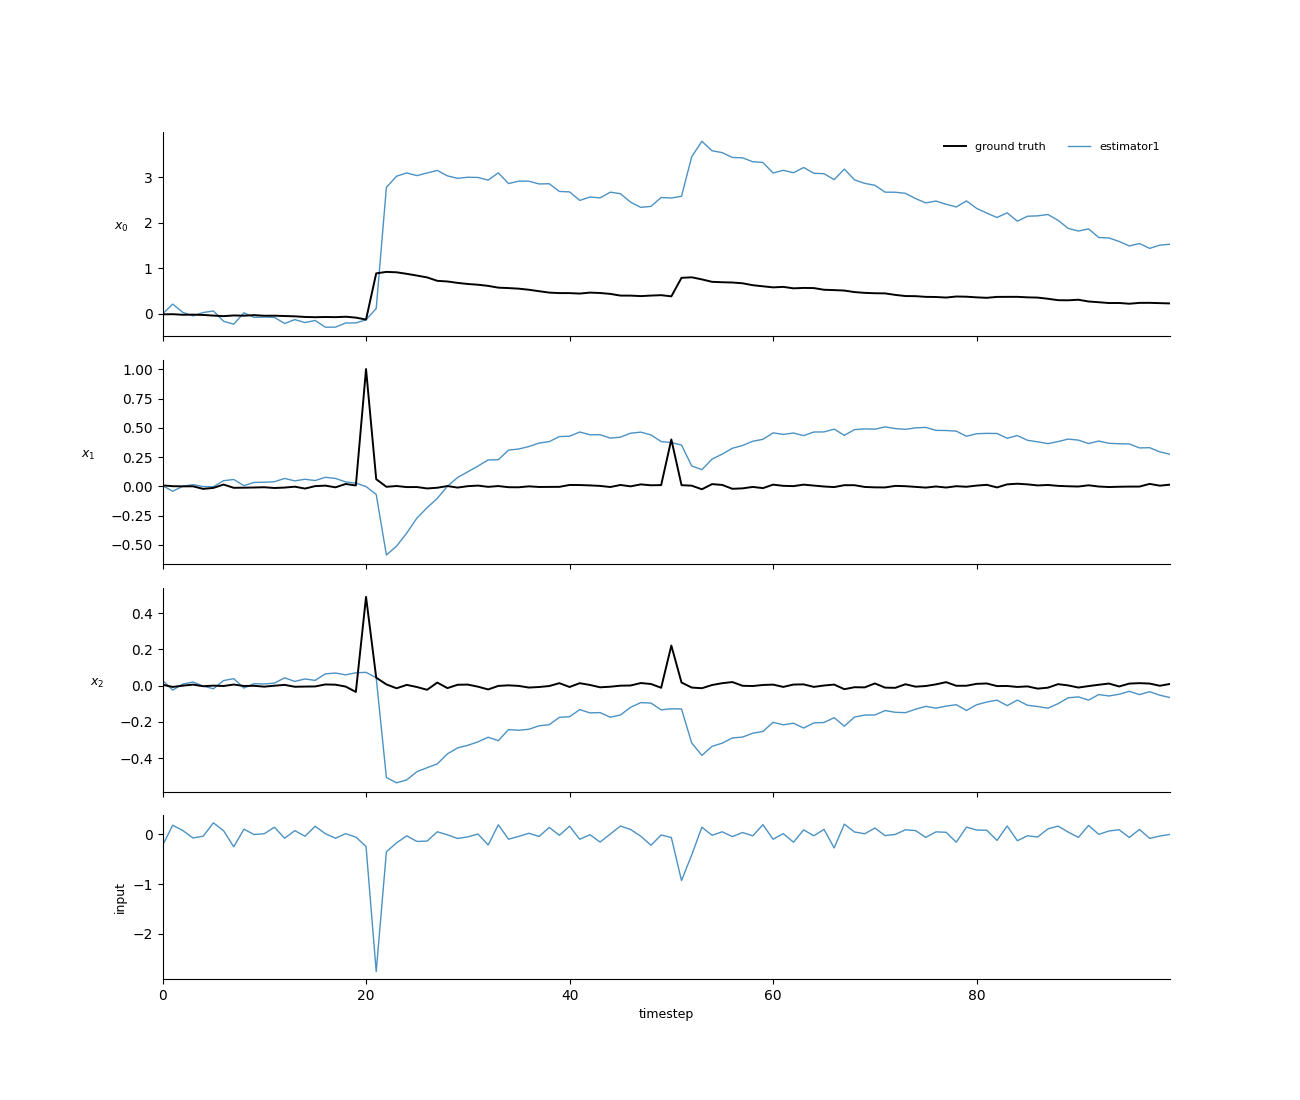

In [289]:
# try:
#     np.load("MethodResults/SparseImpulseInput_Case5.npz")
# except FileNotFoundError:
#     results = run_functions_parallel(
#         functions,
#         observations,
#         latent_dim=3,
#         input_dim=1,
#         max_workers="auto",
#         native_threads_per_worker=1,
#         backend="thread",
#         print_shapes=False,
#     )
#     np.savez("MethodResults/SparseImpulseInput_Case5.npz", **results)

latent_states, inputs = estimate_latent_and_input(observations, LatentDim=3, InputDim=1)
results = {
    "estimator1": {
        "latent_states": latent_states,
        "inputs": inputs,
    }
}

plot_input_latent_comparison_interactive(inputs, states, results, align_inputs=False, align_latents=True, active={})
plt.show()

### Case 6 - transitional growth

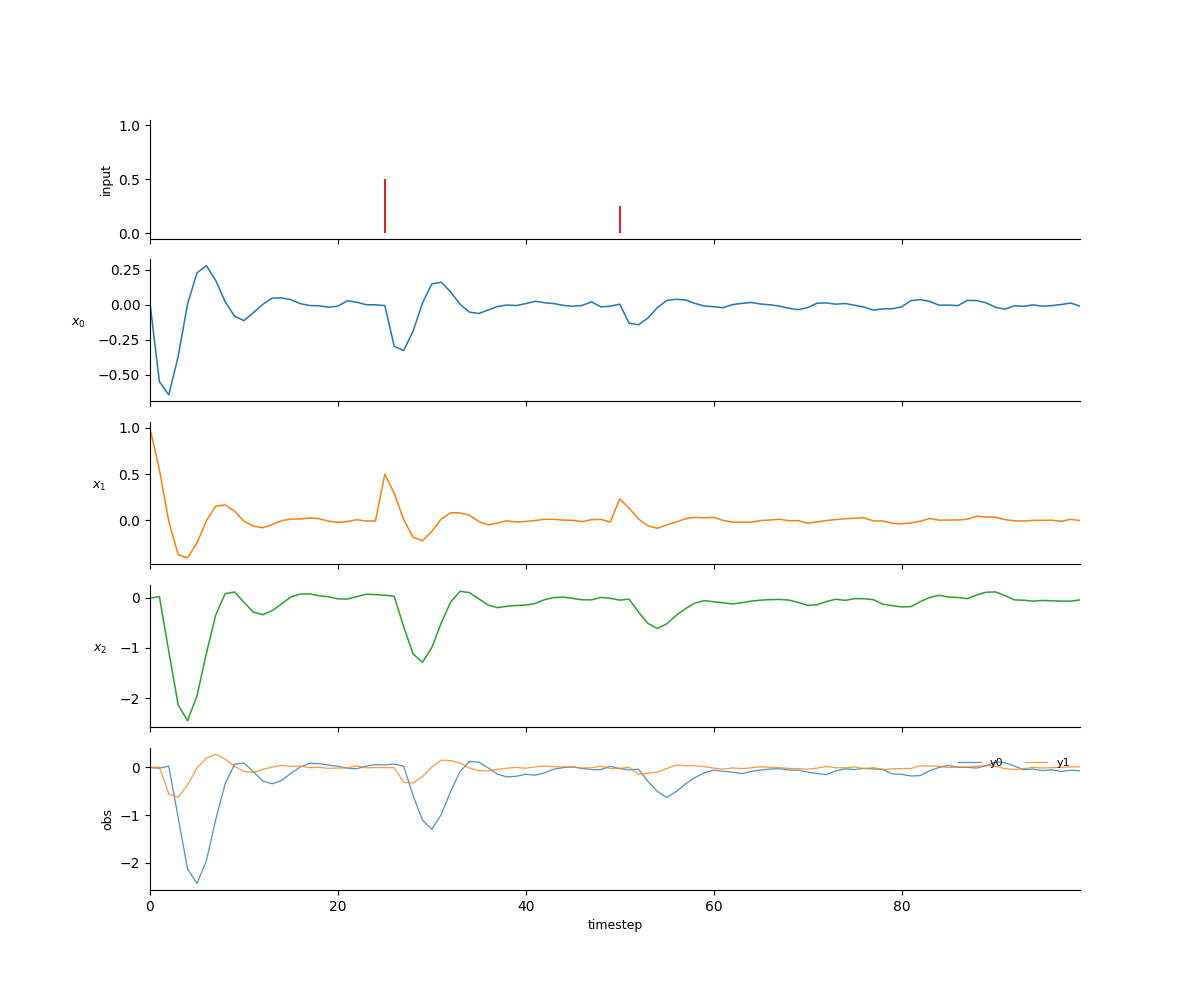

In [290]:
angle = 45 / 180 * np.pi
A = np.array([
    [0.8 * np.cos(angle), -0.8 * np.sin(angle), 0],
    [0.8 * np.sin(angle), 0.8 * np.cos(angle), 0],
    [2, 0, 0.8]
])

B = np.array([[0], [1.0], [0]])

C = np.array([
    [0.0, 0.0, 1.0],
    [1.0, 0.0, 0.0]
])

inputs = np.zeros((100, 1))
inputs[0] = 1
inputs[25] = 0.5
inputs[50] = 0.25

x_noise = np.random.normal(0, 0.01, (100, 3))
y_noise = np.random.normal(0, 0.01, (100, 2))

states, observations = simulate(A, B, C, inputs, x_noise, y_noise)

plot_input_latent_observation(inputs, states, observations)
plt.show()

  EM iter   1  |  LL = -168.1045  |  u_nnz = 96
  EM iter   2  |  LL = -205.7863  |  u_nnz = 98
  EM iter   3  |  LL = -224.3168  |  u_nnz = 98
  EM iter   4  |  LL = -228.6989  |  u_nnz = 98
  EM iter   5  |  LL = -229.5086  |  u_nnz = 99
  EM iter   6  |  LL = -229.6506  |  u_nnz = 99
  EM iter   7  |  LL = -229.6753  |  u_nnz = 99
  EM iter   8  |  LL = -229.6796  |  u_nnz = 99
  Converged at iter 8 (Δ=1.87e-05)


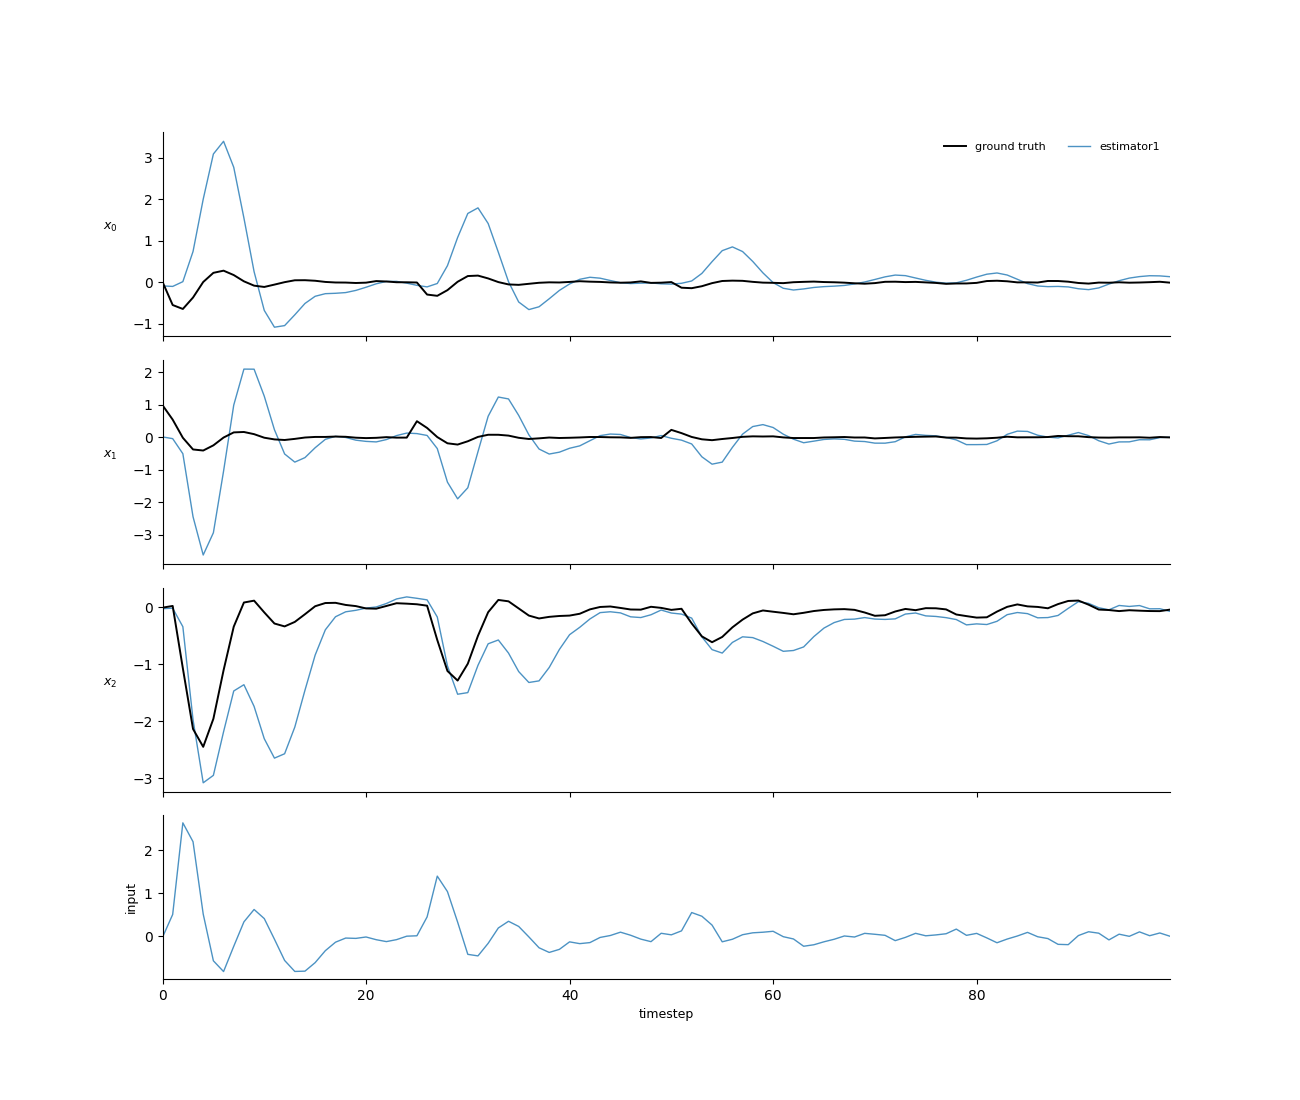

In [291]:
# try:
#     np.load("MethodResults/SparseImpulseInput_Case6.npz")
# except FileNotFoundError:
#     subfunc = {key: func for key, func in functions.items() if not key in ["as3485", "Bartosz", "Fiana", "JerryLiu"]}

#     results = run_functions_parallel(
#         subfunc,
#         observations,
#         latent_dim=3,
#         input_dim=1,
#         max_workers="auto",
#         native_threads_per_worker=1,
#         backend="thread",
#         print_shapes=False,
#     )
#     np.savez("MethodResults/SparseImpulseInput_Case6.npz", **results)

latent_states, inputs = estimate_latent_and_input(observations, LatentDim=3, InputDim=1)
results = {
    "estimator1": {
        "latent_states": latent_states,
        "inputs": inputs,
    }
}

plot_input_latent_comparison_interactive(inputs, states, results, align_inputs=False, align_latents=True, active={})
plt.show()

### Case 7 - hidden driven osc

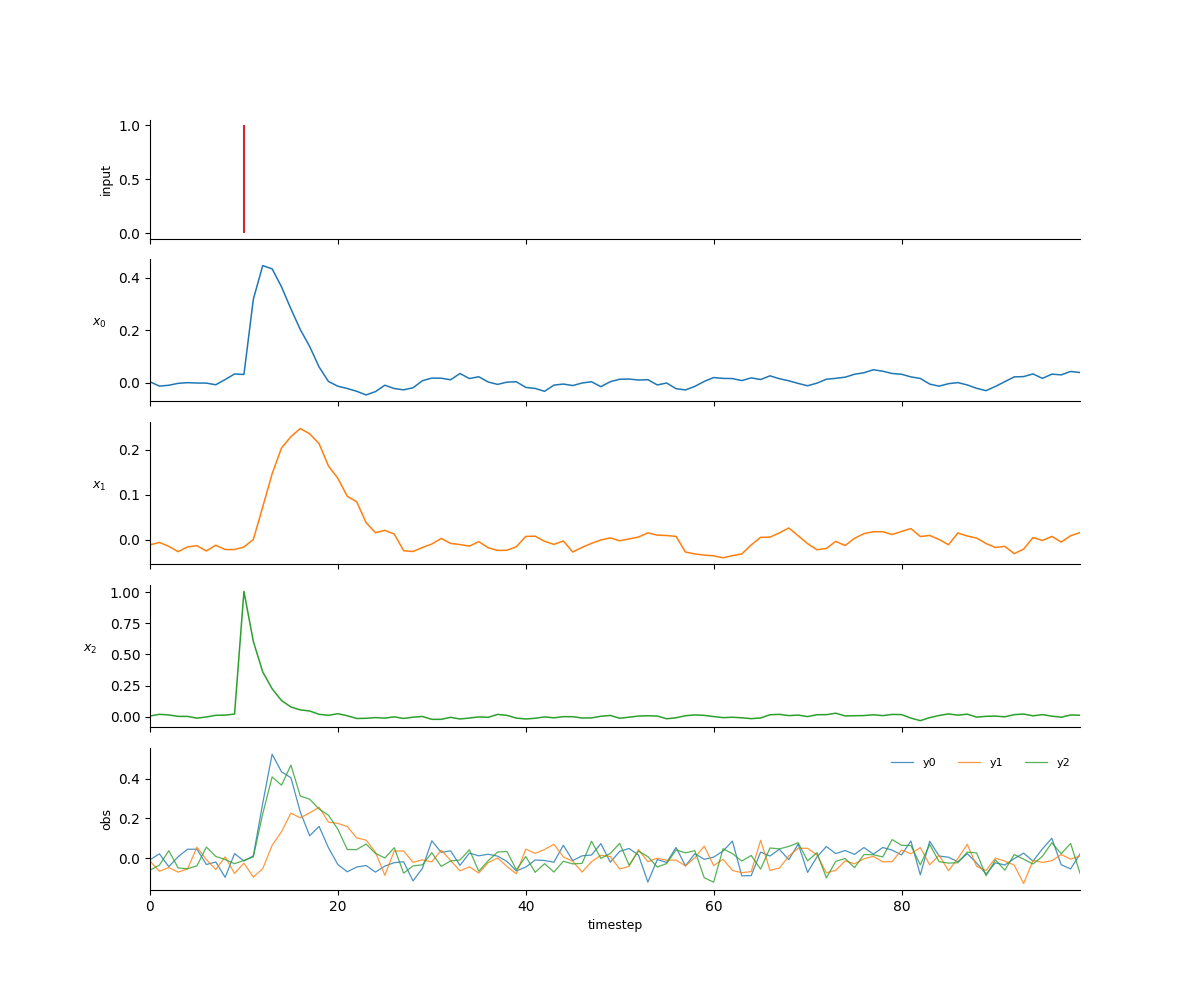

In [292]:
angle = 15 / 180 * np.pi
A = np.array([
    [0.8 * np.cos(angle), -0.8 * np.sin(angle), 0.3],
    [0.8 * np.sin(angle), 0.8 * np.cos(angle), 0],
    [0, 0, 0.6]
])

B = np.array([[0.0], [0.0], [1.0]])

C = np.array([[1.0, 0.0, 0.0],
              [0.0, 1.0, 0.0],
              [0.5, 0.5, 0.0],])
C /= np.linalg.norm(C, axis=1, keepdims=True)

inputs = np.zeros((100, 1))
inputs[10] = 1

x_noise = np.random.normal(0, 0.01, (100, 3))
y_noise = np.random.normal(0, 0.04, (100, 3))

states, observations = simulate(A, B, C, inputs, x_noise, y_noise)

plot_input_latent_observation(inputs, states, observations)
plt.show()

  EM iter   1  |  LL = -203.6735  |  u_nnz = 96
  EM iter   2  |  LL = -251.9492  |  u_nnz = 98
  EM iter   3  |  LL = -276.7148  |  u_nnz = 98
  EM iter   4  |  LL = -282.3122  |  u_nnz = 99
  EM iter   5  |  LL = -283.2426  |  u_nnz = 99
  EM iter   6  |  LL = -283.3877  |  u_nnz = 99
  EM iter   7  |  LL = -283.4101  |  u_nnz = 99
  Converged at iter 7 (Δ=7.90e-05)


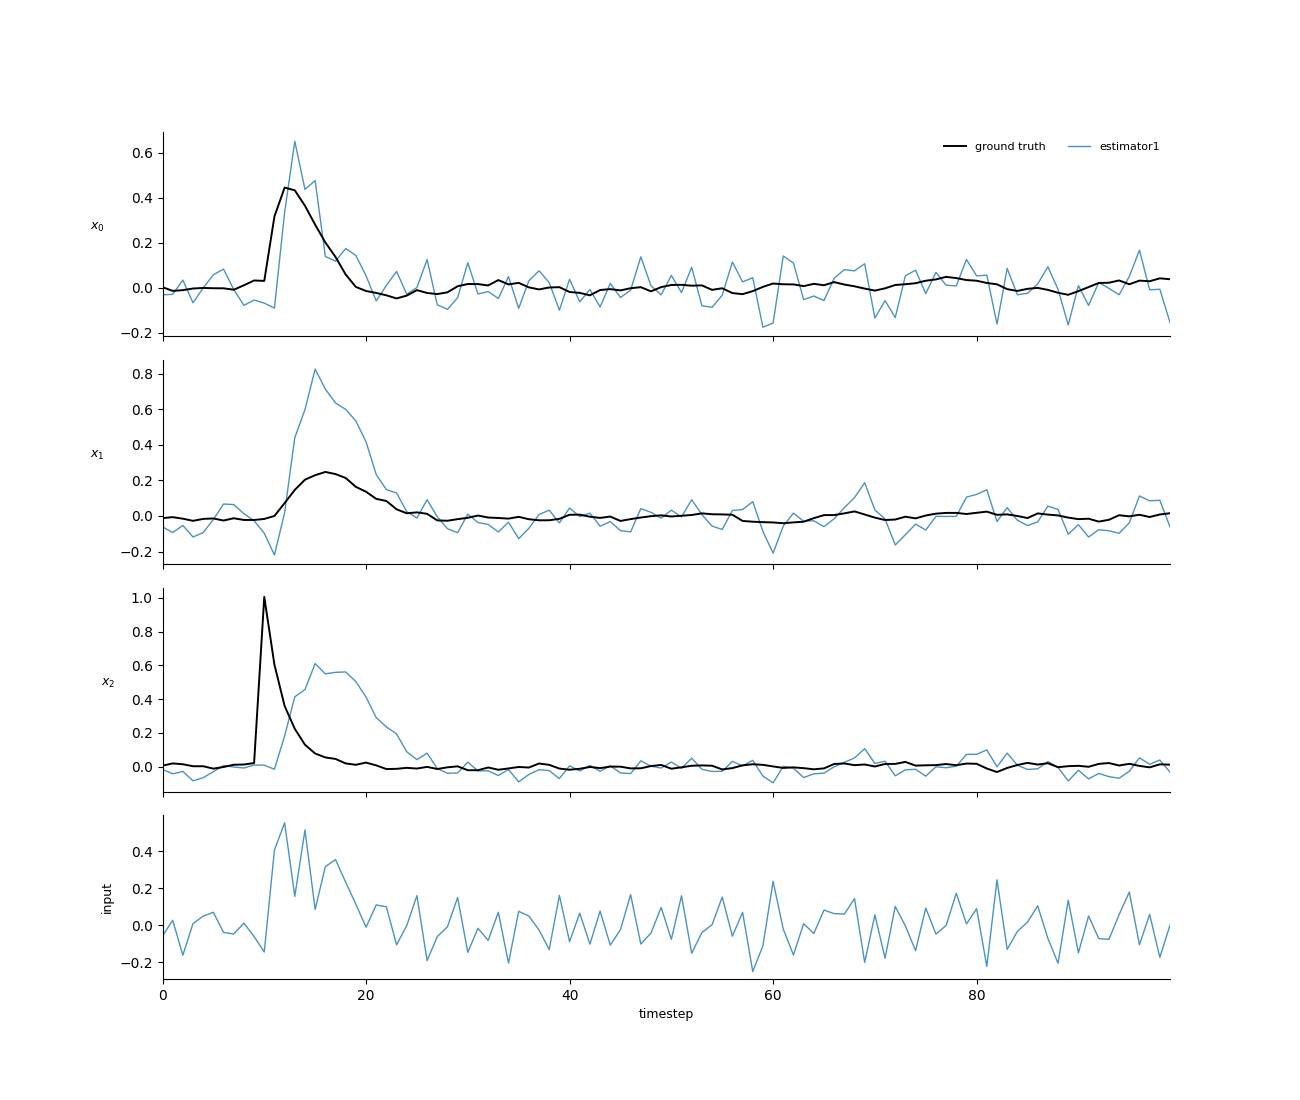

In [293]:
# try:
#     np.load("MethodResults/SparseImpulseInput_Case7.npz")
# except FileNotFoundError:
#     results = run_functions_parallel(
#         functions,
#         observations,
#         latent_dim=3,
#         input_dim=1,
#         max_workers="auto",
#         native_threads_per_worker=1,
#         backend="thread",
#         print_shapes=False,
#     )
#     np.savez("MethodResults/SparseImpulseInput_Case7.npz", **results)

latent_states, inputs = estimate_latent_and_input(observations, LatentDim=3, InputDim=1)
results = {
    "estimator1": {
        "latent_states": latent_states,
        "inputs": inputs,
    }
}

plot_input_latent_comparison_interactive(inputs, states, results, align_inputs=False, align_latents=True, active={})
plt.show()

### Case 8 - High-low freq

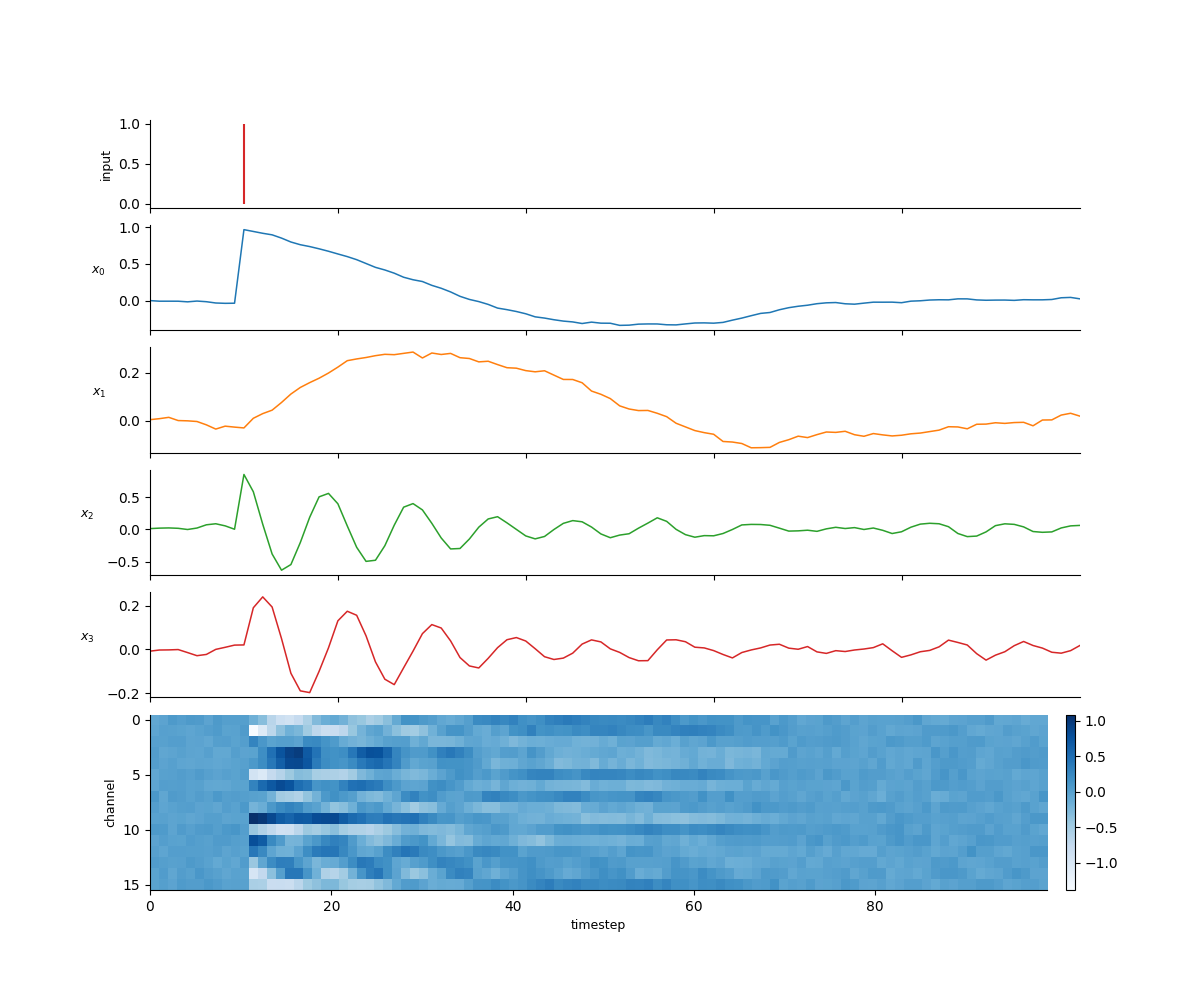

In [294]:
angle_slow = 4 / 180 * np.pi
angle_fast = 40 / 180 * np.pi
A = np.array([
    [0.98 * np.cos(angle_slow), -0.98 * np.sin(angle_slow) * 2, 0, 0],
    [0.98 * np.sin(angle_slow) / 2, 0.98 * np.cos(angle_slow), 0, 0],
    [0, 0, 0.95 * np.cos(angle_fast), -0.95 * np.sin(angle_fast) * 3],
    [0, 0, 0.95 * np.sin(angle_fast) / 3, 0.95 * np.cos(angle_fast)],
])

B = np.array([[1], 
              [0],
              [0.9],
              [0]])

C = np.random.normal(0, 1, (16, 4))
C /= np.linalg.norm(C, axis=1, keepdims=True)

inputs = np.zeros((100, 1))
inputs[10] = 1

x_noise = np.random.normal(0, 0.01, (100, 4))
y_noise = np.random.normal(0, 0.04, (100, 16))

states, observations = simulate(A, B, C, inputs, x_noise, y_noise)

plot_input_latent_observation(inputs, states, observations)
plt.show()

  EM iter   1  |  LL = -992.5189  |  u_nnz = 99
  EM iter   2  |  LL = -1022.6155  |  u_nnz = 96
  EM iter   3  |  LL = -1046.2121  |  u_nnz = 99
  EM iter   4  |  LL = -1054.1466  |  u_nnz = 98
  EM iter   5  |  LL = -1055.9850  |  u_nnz = 99
  EM iter   6  |  LL = -1056.3680  |  u_nnz = 99
  EM iter   7  |  LL = -1056.4459  |  u_nnz = 99
  Converged at iter 7 (Δ=7.38e-05)


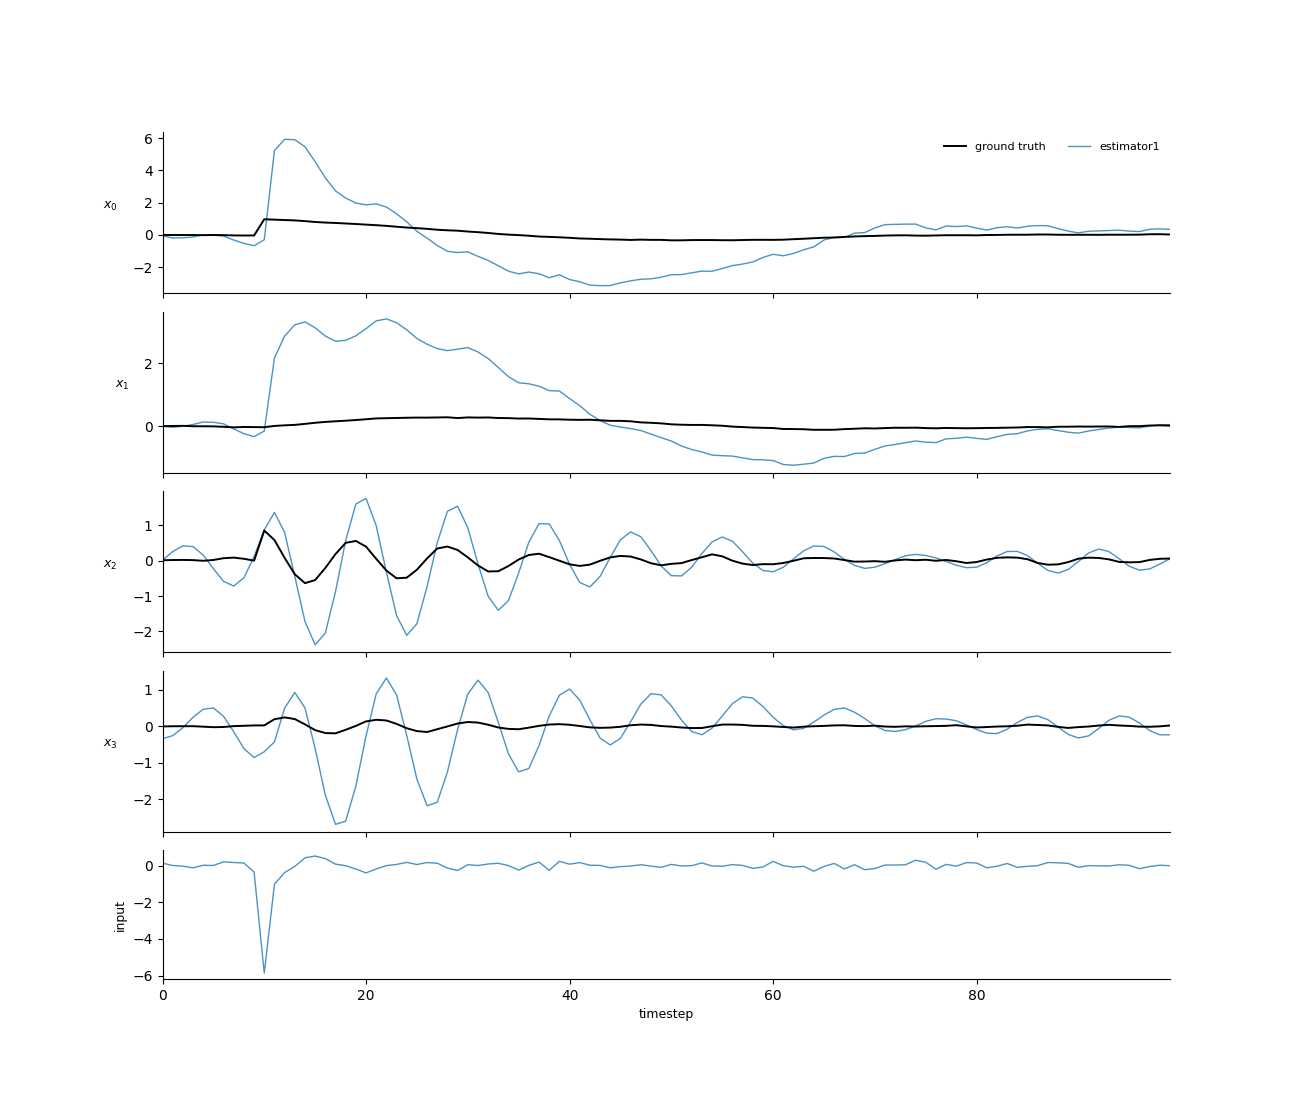

In [295]:
# try:
#     np.load("MethodResults/SparseImpulseInput_Case8.npz")
# except FileNotFoundError:
#     results = run_functions_parallel(
#         functions,
#         observations,
#         latent_dim=4,
#         input_dim=1,
#         max_workers="auto",
#         native_threads_per_worker=1,
#         backend="thread",
#         print_shapes=False,
#     )
#     np.savez("MethodResults/SparseImpulseInput_Case8.npz", **results)

latent_states, inputs = estimate_latent_and_input(observations, LatentDim=4, InputDim=1)
results = {
    "estimator1": {
        "latent_states": latent_states,
        "inputs": inputs,
    }
}

plot_input_latent_comparison_interactive(inputs, states, results, align_inputs=False, align_latents=True, active={})
plt.show()

### Case 9 - Noisy

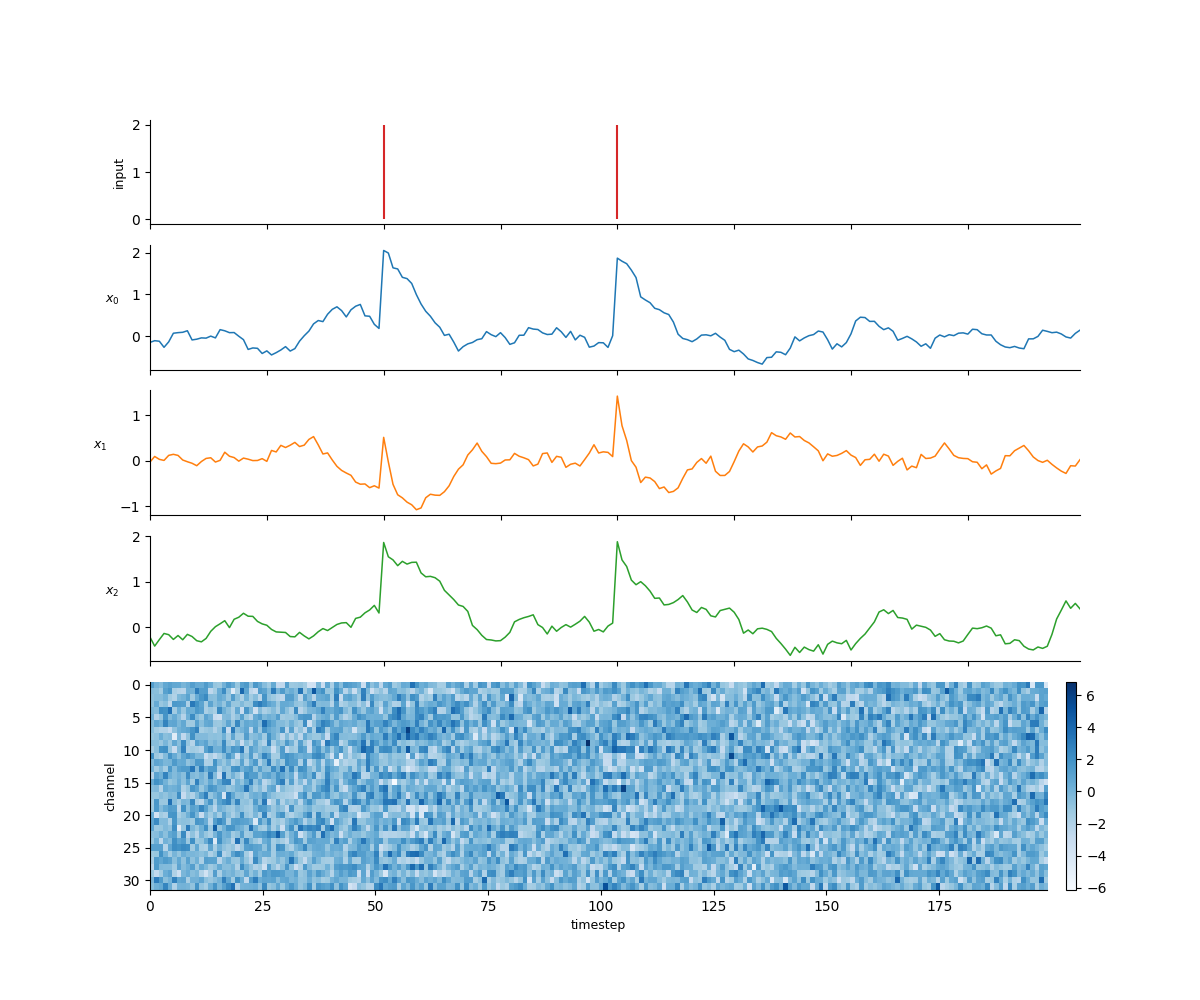

In [296]:
A = np.array([[0.9, 0.1, 0],
              [-0.2, 0.8, 0],
              [0.1, -0.1, 0.8]])

B = np.array([[1], 
              [0.6], 
              [0.8]])

C = np.random.normal(0, 1, (32, 3))
C /= np.linalg.norm(C, axis=1, keepdims=True)


inputs = np.zeros((200, 1))
inputs[50] = 2
inputs[100] = 2

x_noise = np.random.normal(0, 0.1, (200, 3))
y_noise = np.random.normal(0, 1.5, (200, 32))

states, observations = simulate(A, B, C, inputs, x_noise, y_noise)

plot_input_latent_observation(inputs, states, observations)
plt.show()

  EM iter   1  |  LL = -11761.9884  |  u_nnz = 198
  EM iter   2  |  LL = -11780.8598  |  u_nnz = 199
  EM iter   3  |  LL = -11797.1106  |  u_nnz = 199
  EM iter   4  |  LL = -11805.5846  |  u_nnz = 199
  EM iter   5  |  LL = -11809.1809  |  u_nnz = 199
  EM iter   6  |  LL = -11810.5771  |  u_nnz = 199
  EM iter   7  |  LL = -11811.1006  |  u_nnz = 199
  Converged at iter 7 (Δ=4.43e-05)


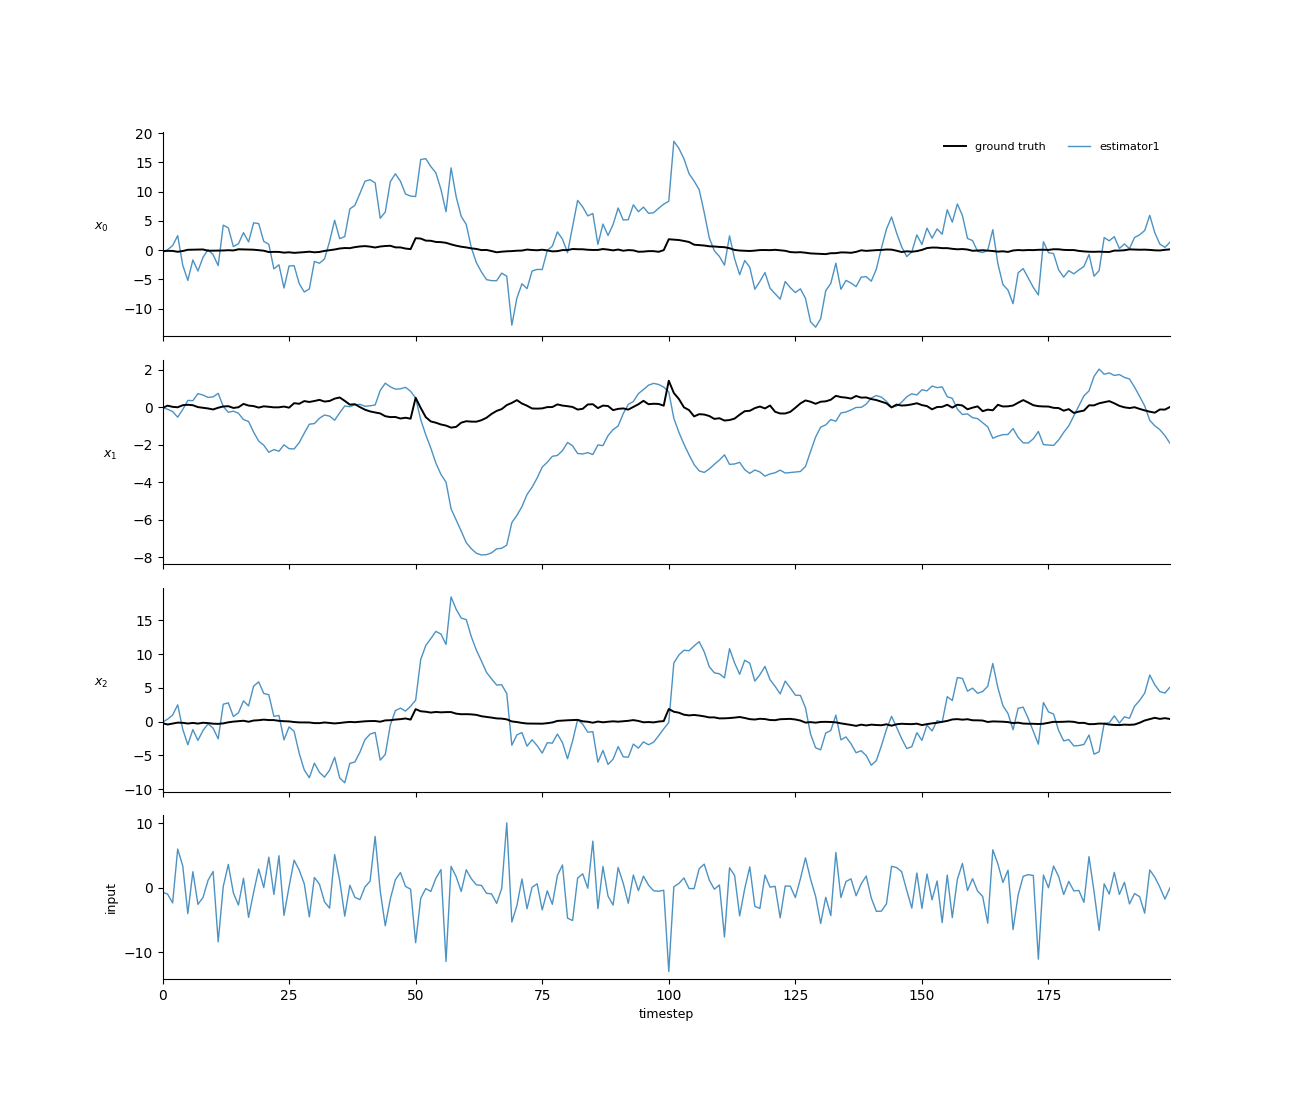

In [297]:
# try:
#     np.load("MethodResults/SparseImpulseInput_Case9.npz")
# except FileNotFoundError:
#     results = run_functions_parallel(
#         functions,
#         observations,
#         latent_dim=3,
#         input_dim=1,
#         max_workers="auto",
#         native_threads_per_worker=1,
#         backend="thread",
#         print_shapes=False,
#     )
#     np.savez("MethodResults/SparseImpulseInput_Case9.npz", **results)

latent_states, inputs = estimate_latent_and_input(observations, LatentDim=3, InputDim=1)
results = {
    "estimator1": {
        "latent_states": latent_states,
        "inputs": inputs,
    }
}

plot_input_latent_comparison_interactive(inputs, states, results, align_inputs=False, align_latents=True, active={})
plt.show()

### Case 10 - Short Time

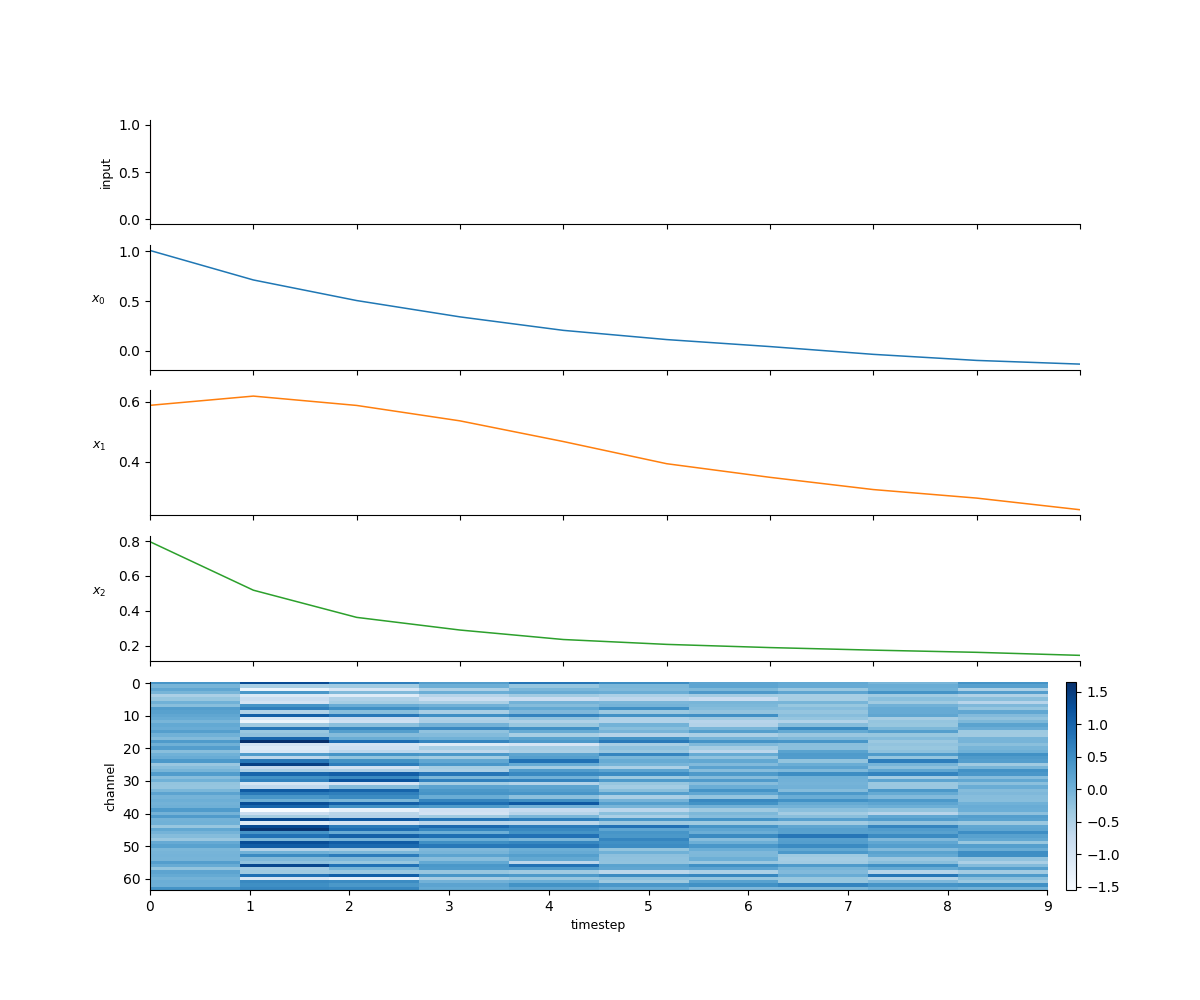

In [298]:
A = np.eye(3) * 0.7 + np.random.normal(0, 0.2, (3, 3))
B = np.array([[1], 
              [0.6], 
              [0.8]])
C = np.random.normal(0, 1, (64, 3))
C /= np.linalg.norm(C, axis=1, keepdims=True)

inputs = np.zeros((10, 1))
inputs[0] = 1

x_noise = np.random.normal(0, 0.01, (10, 3))
y_noise = np.random.normal(0, 0.2, (10, 64))

states, observations = simulate(A, B, C, inputs, x_noise, y_noise)

plot_input_latent_observation(inputs, states, observations)
plt.show()

In [299]:
# try:
#     np.load("MethodResults/SparseImpulseInput_Case10.npz")
# except FileNotFoundError:
#     subfuncs = {key: func for key, func in functions.items() if not key in ["Tahmid", ]}

#     results = run_functions_parallel(
#         subfuncs,
#         observations,
#         latent_dim=3,
#         input_dim=1,
#         max_workers="auto",
#         native_threads_per_worker=1,
#         backend="thread",
#         print_shapes=False,
#     )
#     np.savez("MethodResults/SparseImpulseInput_Case10.npz", **results)

# results = run_functions_parallel(
#     functions,
#     observations,
#     latent_dim=3,
#     input_dim=1,
#     max_workers="auto",
#     native_threads_per_worker=1,
#     backend="thread",
#     print_shapes=False,
# )


# plot_input_latent_comparison_interactive(inputs, states, results, align_inputs=False, align_latents=True, active={})
# plt.show()

### Case 11 - Inadequate Latents

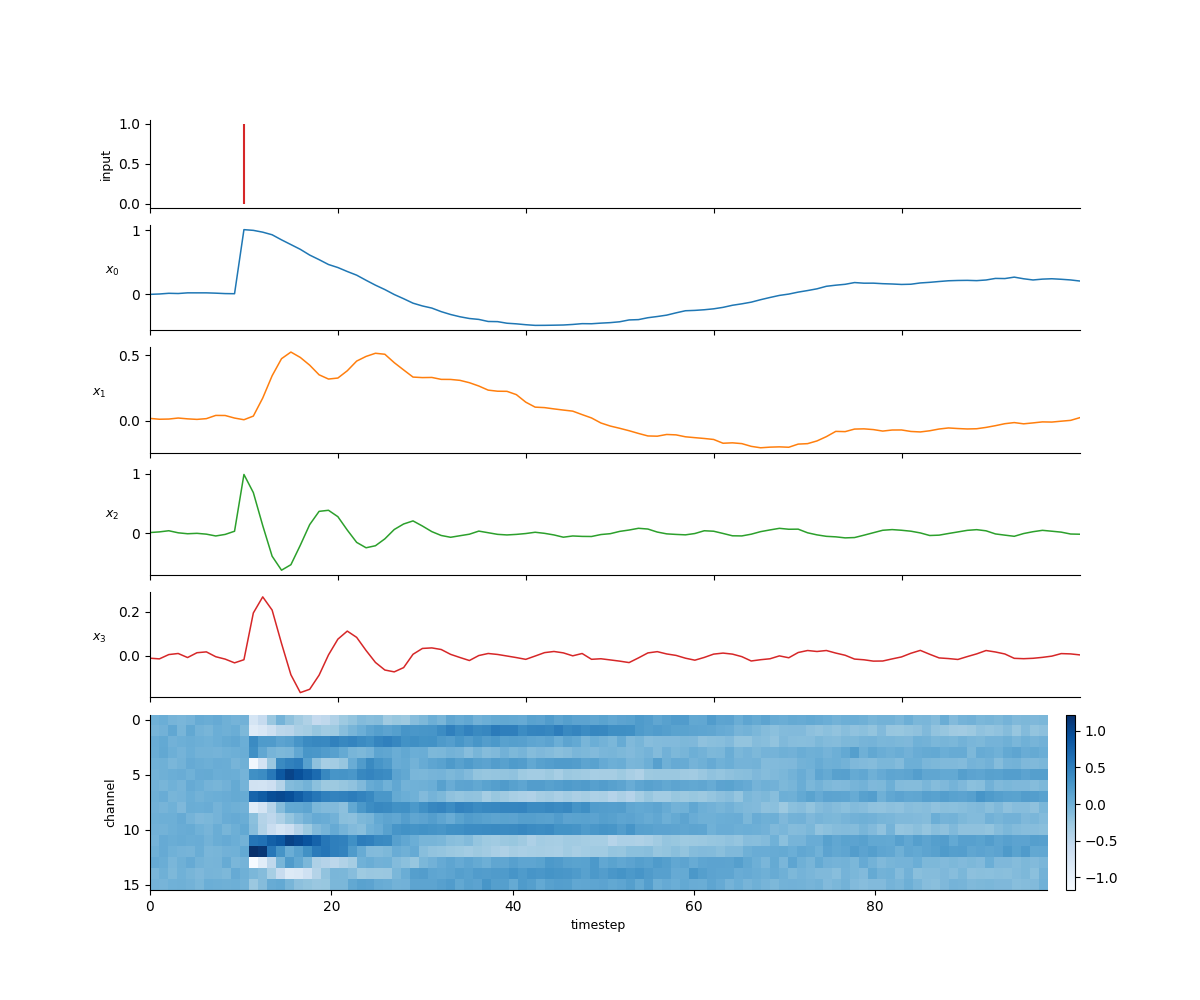

In [300]:
angle_slow = 4 / 180 * np.pi
angle_fast = 40 / 180 * np.pi
A = np.array([
    [0.98 * np.cos(angle_slow), -0.98 * np.sin(angle_slow) * 2, 0, 0],
    [0.98 * np.sin(angle_slow) / 2, 0.98 * np.cos(angle_slow), 0, 0.5],
    [0, 0, 0.9 * np.cos(angle_fast), -0.9 * np.sin(angle_fast) * 3],
    [0, 0, 0.9 * np.sin(angle_fast) / 3, 0.9 * np.cos(angle_fast)],
])

B = np.array([[1], 
              [0],
              [0.9],
              [0]])

C = np.random.normal(0, 1, (16, 4))
C /= np.linalg.norm(C, axis=1, keepdims=True)

inputs = np.zeros((100, 1))
inputs[10] = 1

x_noise = np.random.normal(0, 0.01, (100, 4))
y_noise = np.random.normal(0, 0.04, (100, 16))

states, observations = simulate(A, B, C, inputs, x_noise, y_noise)

plot_input_latent_observation(inputs, states, observations)
plt.show()

In [301]:
# try:
#     np.load("MethodResults/SparseImpulseInput_Case11.npz")
# except FileNotFoundError:
#     results = run_functions_parallel(
#         functions,
#         observations,
#         latent_dim=2,
#         input_dim=1,
#         max_workers="auto",
#         native_threads_per_worker=1,
#         backend="thread",
#         print_shapes=False,
#     )
#     np.savez("MethodResults/SparseImpulseInput_Case11.npz", **results)


# results = run_functions_parallel(
#         functions,
#         observations,
#         latent_dim=2,
#         input_dim=1,
#         max_workers="auto",
#         native_threads_per_worker=1,
#         backend="thread",
#         print_shapes=False,
#     )

# plot_input_latent_comparison_interactive(inputs, states, results, align_inputs=False, align_latents=True, active={})
# plt.show()

### Case 12 - overcomplex assumption

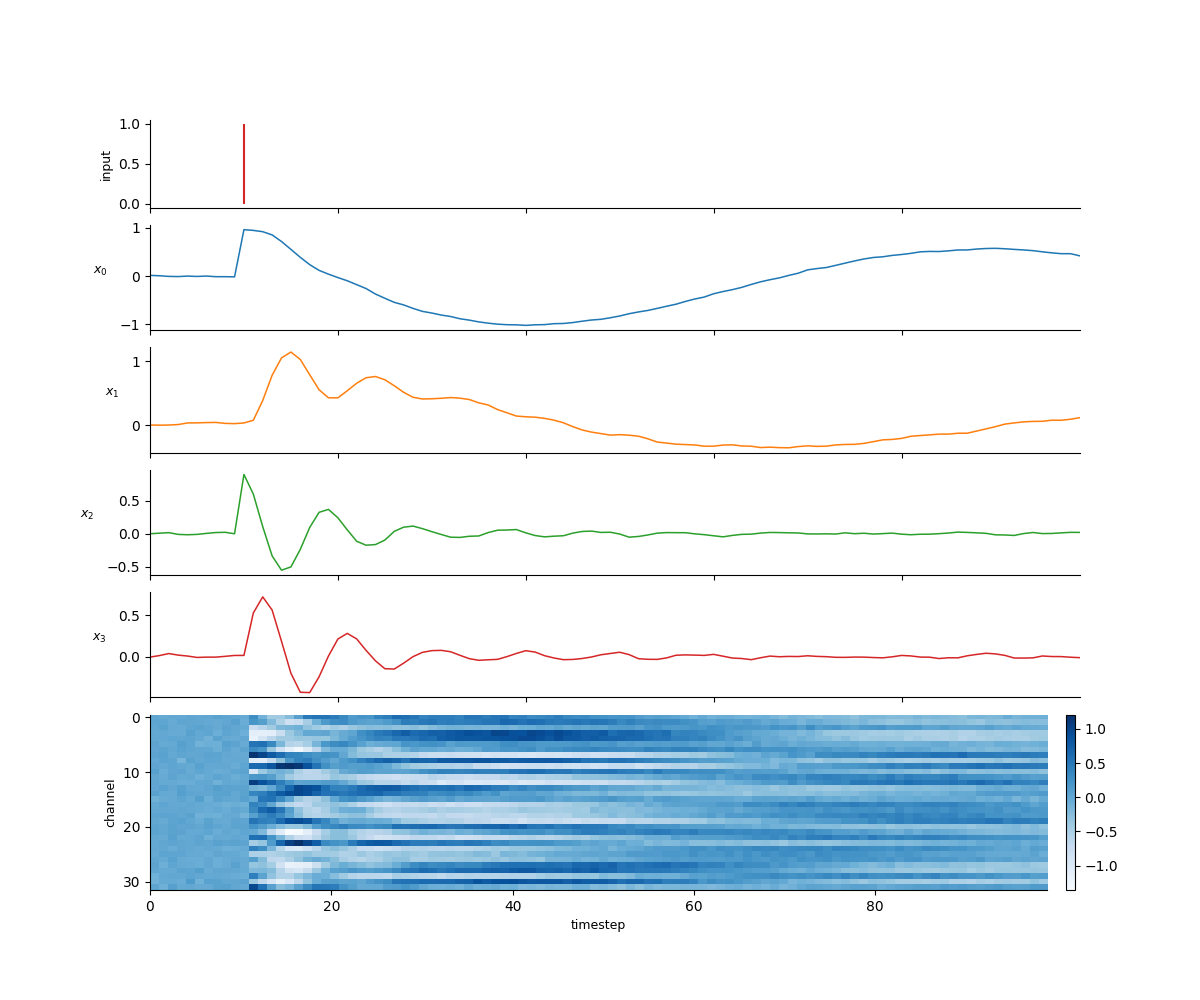

In [302]:
angle_slow = 4 / 180 * np.pi
angle_fast = 40 / 180 * np.pi
A = np.array([
    [0.98 * np.cos(angle_slow), -0.98 * np.sin(angle_slow) * 2, 0, 0],
    [0.98 * np.sin(angle_slow) / 2, 0.98 * np.cos(angle_slow), 0, 0.5],
    [0, 0, 0.9 * np.cos(angle_fast), -0.9 * np.sin(angle_fast)],
    [0, 0, 0.9 * np.sin(angle_fast), 0.9 * np.cos(angle_fast)],
])

B = np.array([[1], 
              [0],
              [0.9],
              [0]])

C = np.random.normal(0, 1, (32, 4))
C /= np.linalg.norm(C, axis=1, keepdims=True)

inputs = np.zeros((100, 1))
inputs[10] = 1

x_noise = np.random.normal(0, 0.01, (100, 4))
y_noise = np.random.normal(0, 0.04, (100, 32))

states, observations = simulate(A, B, C, inputs, x_noise, y_noise)

plot_input_latent_observation(inputs, states, observations)
plt.show()

In [303]:
# try:
#     np.load("MethodResults/SparseImpulseInput_Case12.npz")
# except FileNotFoundError:
#     results = run_functions_parallel(
#         functions,
#         observations,
#         latent_dim=8,
#         input_dim=1,
#         max_workers="auto",
#         native_threads_per_worker=1,
#         backend="thread",
#         print_shapes=False,
#     )
#     np.savez("MethodResults/SparseImpulseInput_Case12.npz", **results)

# results = run_functions_parallel(
#     functions,
#     observations,
#     latent_dim=8,
#     input_dim=1,
#     max_workers="auto",
#     native_threads_per_worker=1,
#     backend="thread",
#     print_shapes=False,
# )
# plot_input_latent_comparison_interactive(inputs, states, results, align_inputs=False, align_latents=True, active={})
# plt.show()

### Case 13 - Low output dim

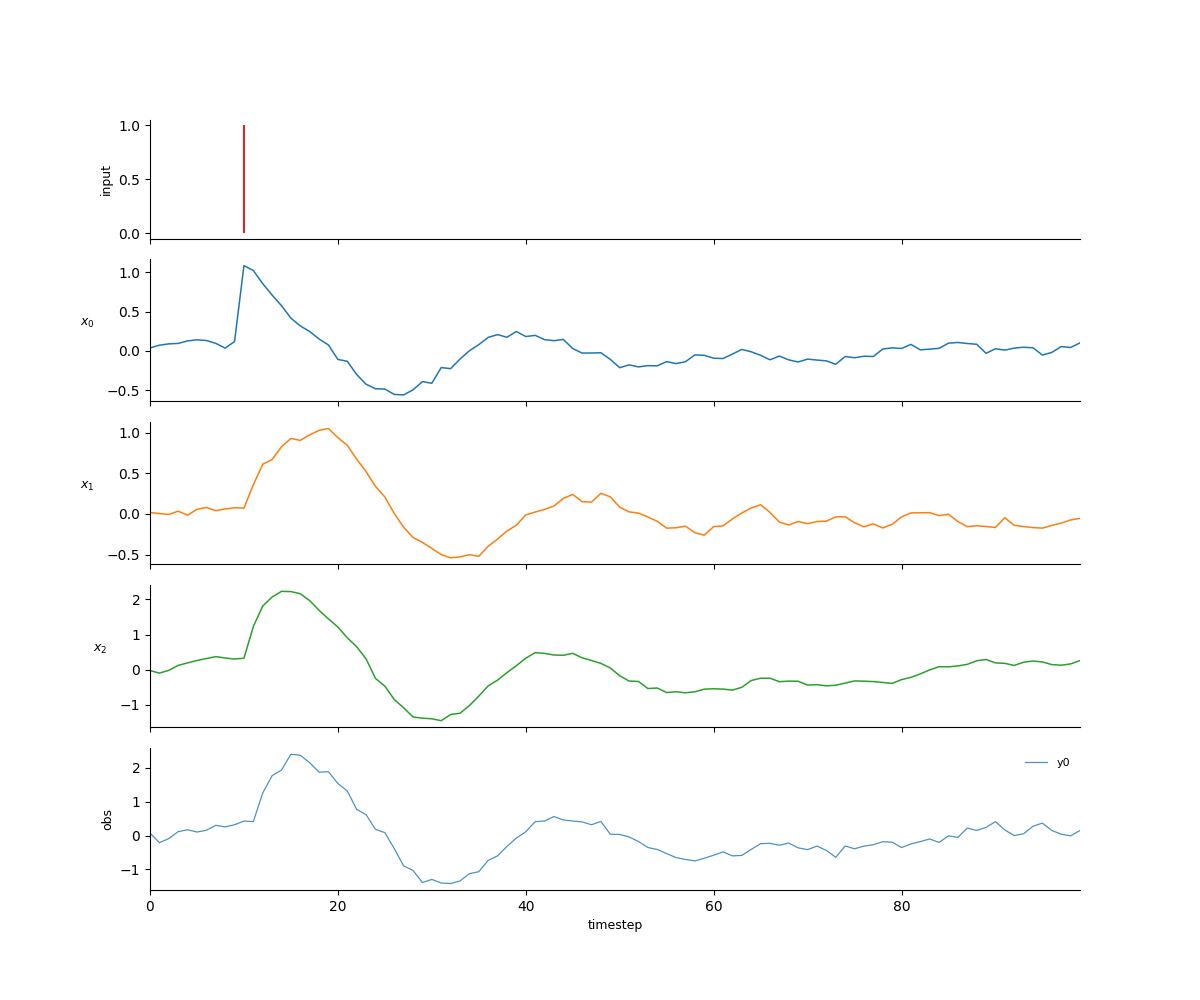

In [304]:
angle = 10 / 180 * np.pi
A = np.array([
    [0.95 * np.cos(angle), -0.95 * np.sin(angle) / 1.5, 0],
    [0.95 * np.sin(angle) * 1.5, 0.90 * np.cos(angle), 0],
    [0.8, 0, 0.8]
])

B = np.array([[1.0], [0.0], [0.0]])

C = np.array([[0.0, 0.0, 1.0]])
C /= np.linalg.norm(C, axis=1, keepdims=True)

inputs = np.zeros((100, 1))
inputs[10] = 1

x_noise = np.random.normal(0, 0.05, (100, 3))
y_noise = np.random.normal(0, 0.1, (100, 1))

states, observations = simulate(A, B, C, inputs, x_noise, y_noise)

plot_input_latent_observation(inputs, states, observations)
plt.show()

  EM iter   1  |  LL = -122.0091  |  u_nnz = 99
  EM iter   2  |  LL = -163.9160  |  u_nnz = 98
  EM iter   3  |  LL = -183.2134  |  u_nnz = 99
  EM iter   4  |  LL = -187.2228  |  u_nnz = 99
  EM iter   5  |  LL = -187.8668  |  u_nnz = 99
  EM iter   6  |  LL = -187.9654  |  u_nnz = 99
  EM iter   7  |  LL = -187.9804  |  u_nnz = 99
  Converged at iter 7 (Δ=7.97e-05)


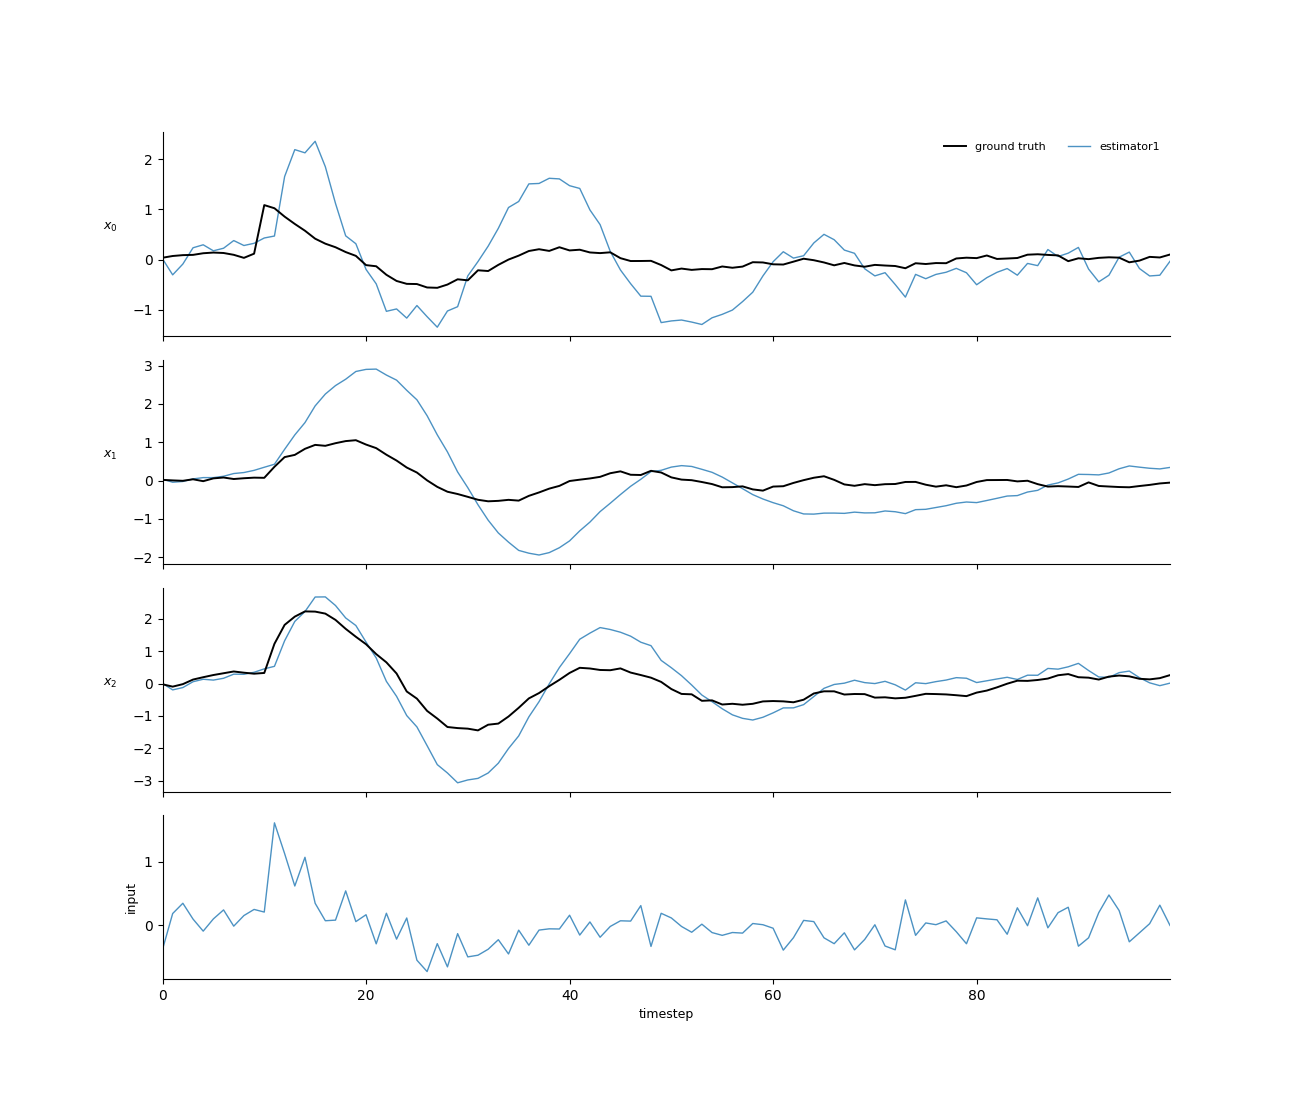

In [305]:
# try:
#     np.load("MethodResults/SparseImpulseInput_Case13.npz")
# except FileNotFoundError:
#     subfunc = {key: func for key, func in functions.items() if not key in ["Bartosz", "Fiana", "as3485"]}

#     results = run_functions_parallel(
#         subfunc,
#         observations,
#         latent_dim=3,
#         input_dim=1,
#         max_workers="auto",
#         native_threads_per_worker=1,
#         backend="thread",
#         print_shapes=False,
#     )
#     np.savez("MethodResults/SparseImpulseInput_Case13.npz", **results)


latent_states, inputs = estimate_latent_and_input(observations, LatentDim=3, InputDim=1)
results = {
    "estimator1": {
        "latent_states": latent_states,
        "inputs": inputs,
    }
}


plot_input_latent_comparison_interactive(inputs, states, results, align_inputs=False, align_latents=True, active={})
plt.show()

### Case 14 - No input noise driven

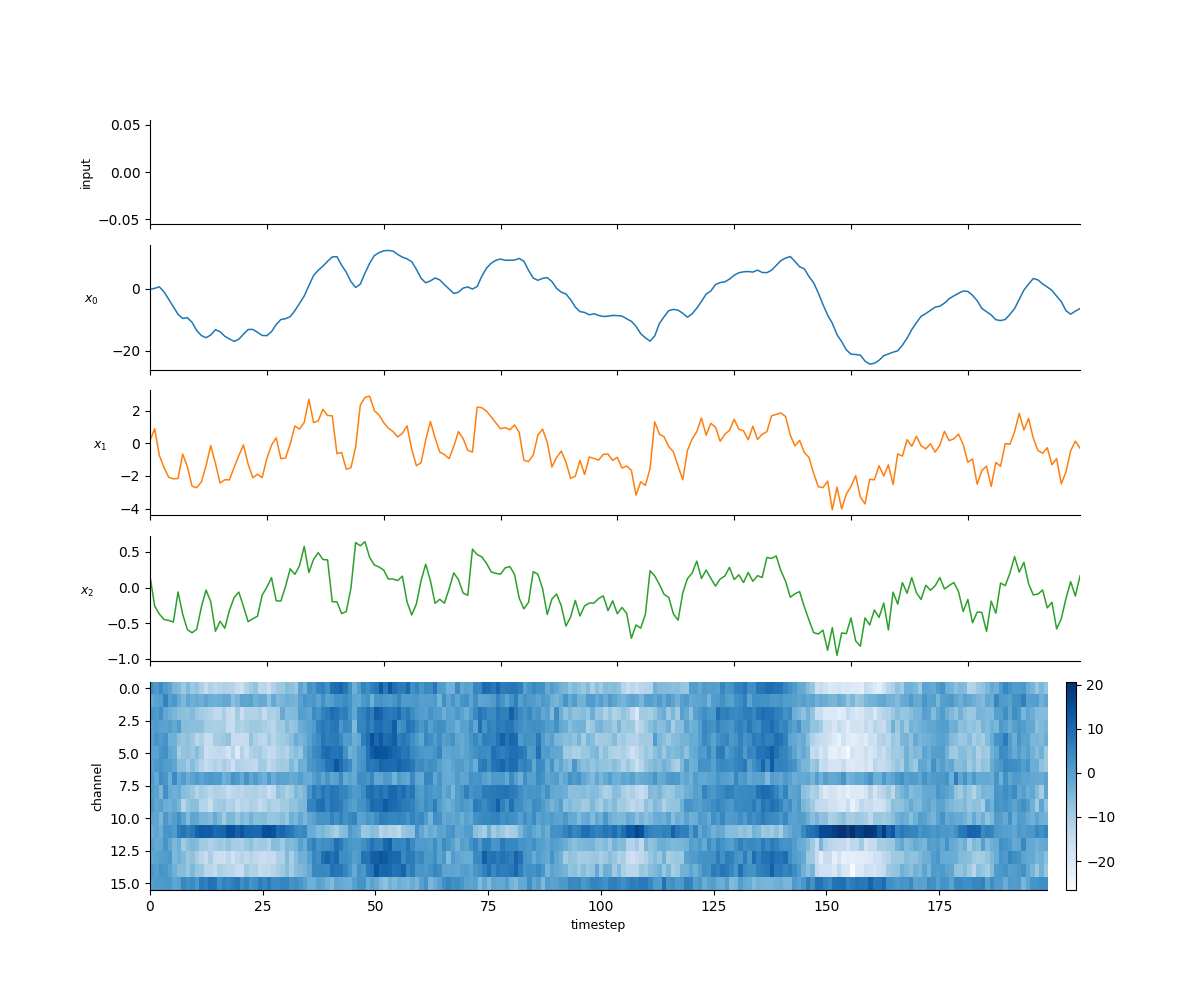

In [306]:
A = np.array([[0.85, 1, 2],
              [0, 0.1, 4],
              [0, 0, 0.8]])

B = np.array([[0], [0], [0.1]])

C = np.random.normal(0, 0.1, (16, 3))
C[:, 0] += np.abs(np.random.normal(0, 0.2, (16,))) + 0.1
C /= np.linalg.norm(C, axis=1, keepdims=True)

inputs = np.zeros((200, 1))

x_noise = np.random.normal(0, 0.2, (200, 3))
y_noise = np.random.normal(0, 2, (200, 16))

states, observations = simulate(A, B, C, inputs, x_noise, y_noise)

plot_input_latent_observation(inputs, states, observations)
plt.show()

  EM iter   1  |  LL = -7374.2937  |  u_nnz = 199
  EM iter   2  |  LL = -7366.5179  |  u_nnz = 199
  EM iter   3  |  LL = -7363.1902  |  u_nnz = 199
  EM iter   4  |  LL = -7361.7701  |  u_nnz = 199
  EM iter   5  |  LL = -7361.1465  |  u_nnz = 199
  Converged at iter 5 (Δ=8.47e-05)


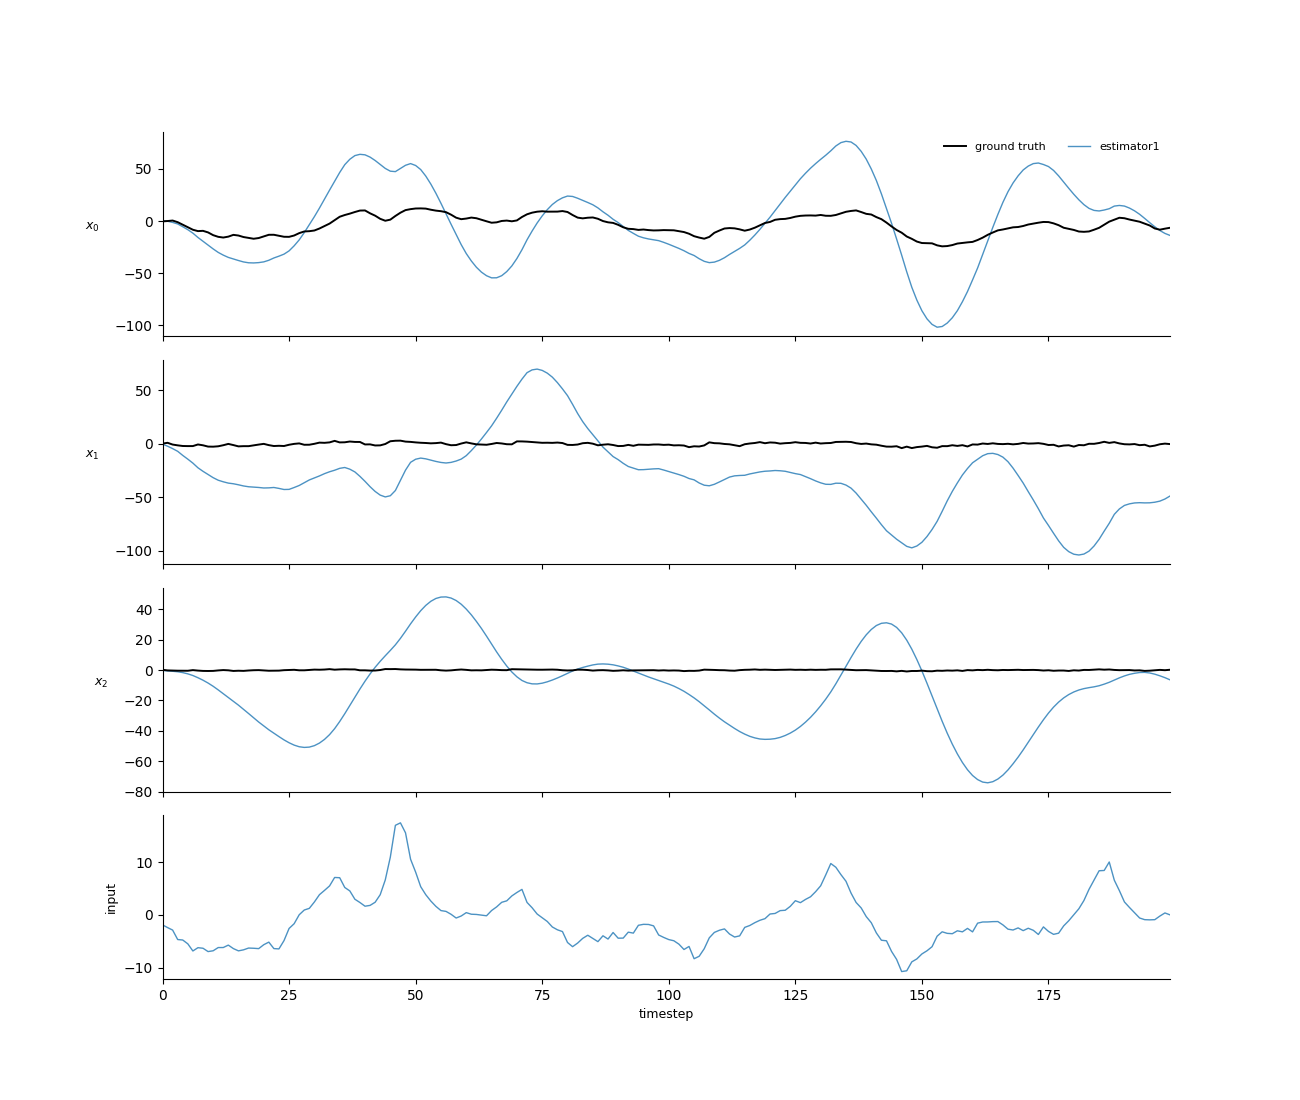

In [307]:
# try:
#     np.load("MethodResults/SparseImpulseInput_Case14.npz")
# except FileNotFoundError:
#     results = run_functions_parallel(
#         functions,
#         observations,
#         latent_dim=3,
#         input_dim=1,
#         max_workers="auto",
#         native_threads_per_worker=1,
#         backend="thread",
#         print_shapes=False,
#     )
#     np.savez("MethodResults/SparseImpulseInput_Case14.npz", **results)


latent_states, inputs = estimate_latent_and_input(observations, LatentDim=3, InputDim=1)
results = {
    "estimator1": {
        "latent_states": latent_states,
        "inputs": inputs,
    }
}


plot_input_latent_comparison_interactive(inputs, states, results, align_inputs=False, align_latents=True, active={})
plt.show()

## Min-energy Input

### Case 1 - null-space injection

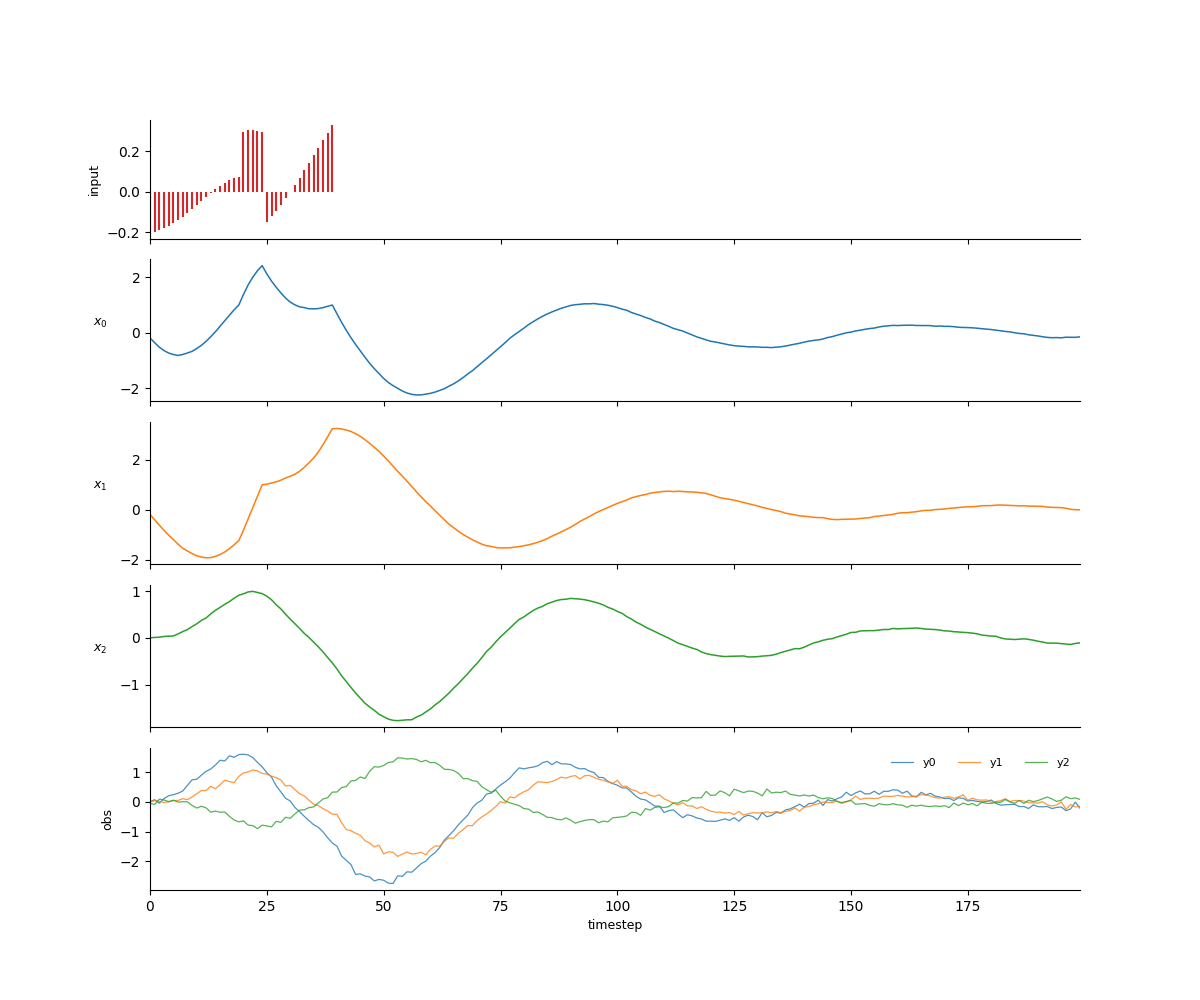

In [308]:
angle = 5 / 180 * np.pi
A = np.array([[np.cos(angle) * 0.98, -np.sin(angle) * 0.98, 0],
              [np.sin(angle) * 0.98, np.cos(angle) * 0.98, 0],
              [0.1, -0.1, 0.8]])

B = np.array([[1], 
              [1], 
              [0]])

C = np.array([[1, -1, 0], 
              [0, 0, 1], 
              [0.1, -0.098, -1]])
C /= np.linalg.norm(C, axis=1, keepdims=True)

x_noise = np.random.normal(0, 0.1, (200, 3))
y_noise = np.random.normal(0, 0.1, (200, 3))

waypoints = {
    (20, 0): 1,
    (25, 1): 1,
    (23, 2): 1,
    (40, 0): 1,
}

x_noise = np.random.normal(0, 0.01, (200, 3))
y_noise = np.random.normal(0, 0.05, (200, 3))

states, observations, inputs, noiseless_states = simulate_from_latents(
    A, B, C,
    latents=waypoints,
    x_noise=x_noise,
    y_noise=y_noise,
    maxu=1.0,
)

plot_input_latent_observation(inputs, states, observations)
plt.show()

  EM iter   1  |  LL = -498.1084  |  u_nnz = 196
  EM iter   2  |  LL = -540.7859  |  u_nnz = 198
  EM iter   3  |  LL = -576.3381  |  u_nnz = 198
  EM iter   4  |  LL = -591.8400  |  u_nnz = 197
  EM iter   5  |  LL = -596.7871  |  u_nnz = 199
  EM iter   6  |  LL = -598.1937  |  u_nnz = 197
  EM iter   7  |  LL = -598.5798  |  u_nnz = 197
  EM iter   8  |  LL = -598.6848  |  u_nnz = 197
  EM iter   9  |  LL = -598.7133  |  u_nnz = 197
  Converged at iter 9 (Δ=4.76e-05)


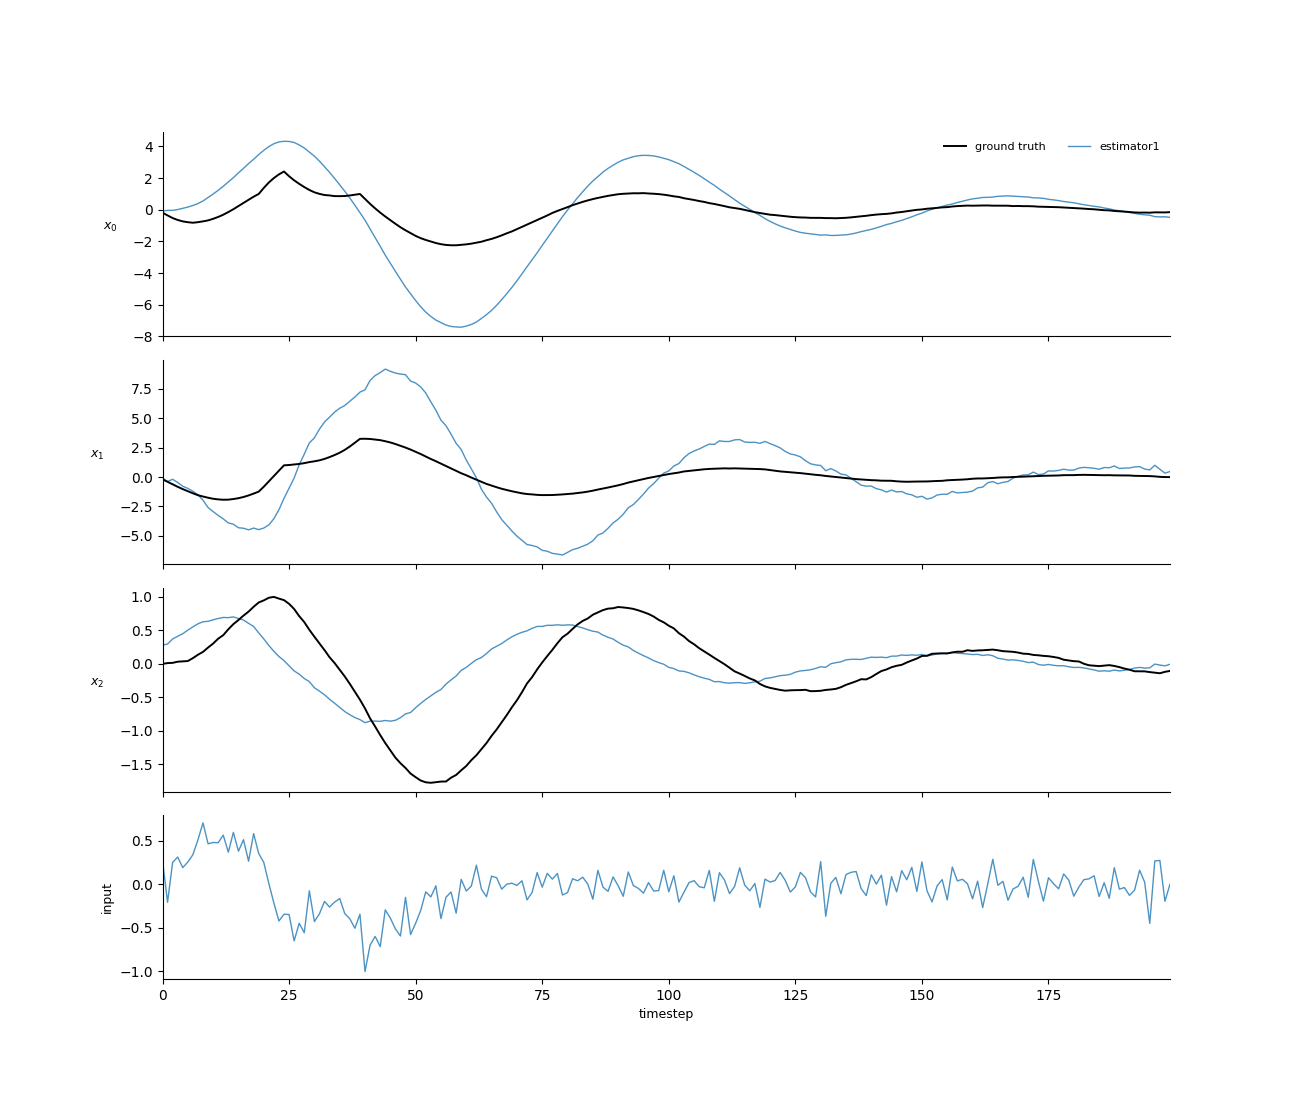

In [309]:
# try:
#     np.load("MethodResults/MinEnergyInput_Case1.npz")
# except FileNotFoundError:
#     results = run_functions_parallel(
#         functions,
#         observations,
#         latent_dim=3,
#         input_dim=1,
#         max_workers="auto",
#         native_threads_per_worker=1,
#         backend="thread",
#         print_shapes=False,
#     )
#     np.savez("MethodResults/MinEnergyInput_Case1.npz", **results)

latent_states, inputs = estimate_latent_and_input(observations, LatentDim=3, InputDim=1)
results = {
    "estimator1": {
        "latent_states": latent_states,
        "inputs": inputs,
    }
}


plot_input_latent_comparison_interactive(inputs, states, results, align_inputs=False, align_latents=True, active={})
plt.show()

### Case 2 - null-space injection and hold

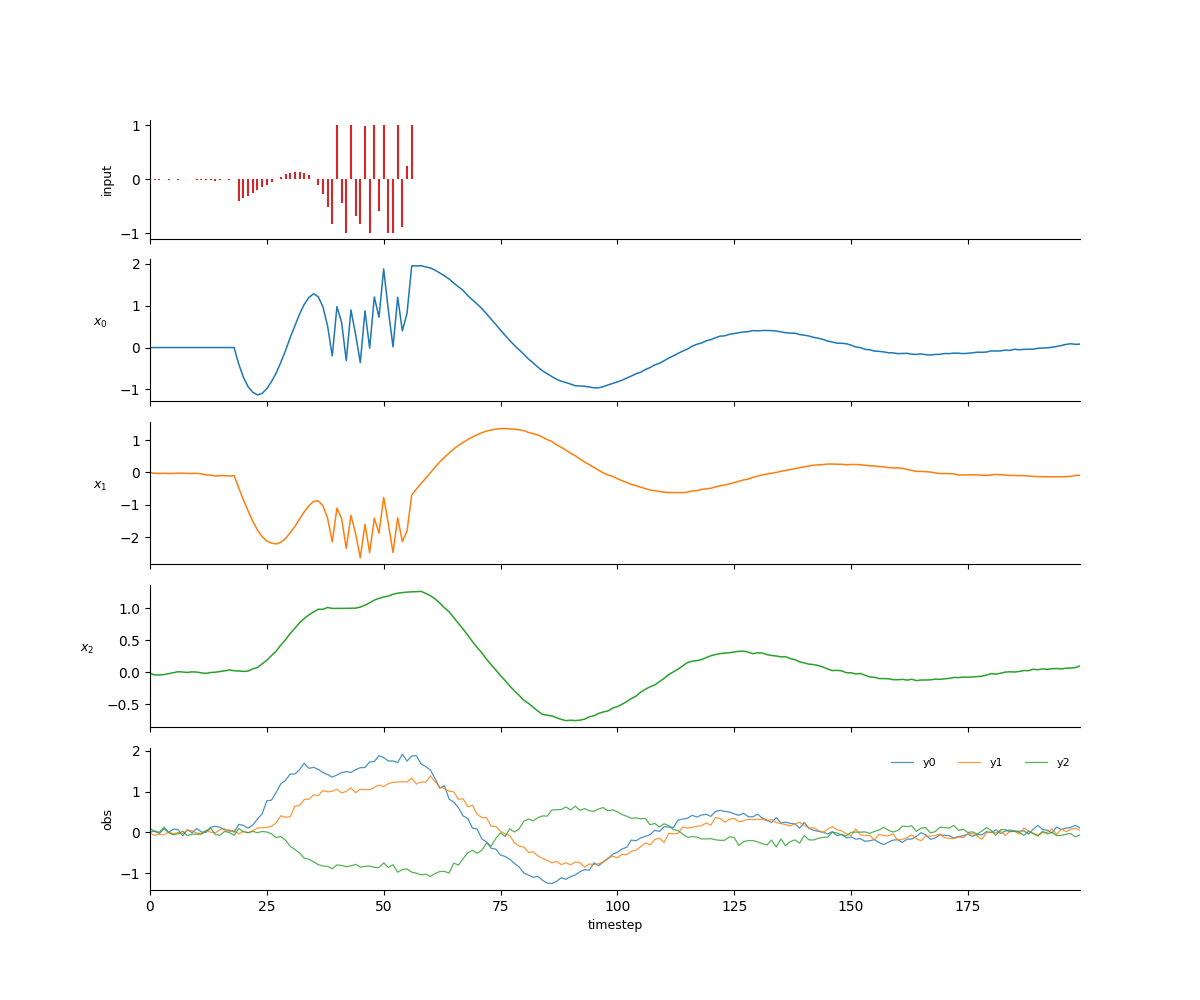

In [310]:
angle = 5 / 180 * np.pi
A = np.array([[np.cos(angle) * 0.98, -np.sin(angle) * 0.98, 0],
              [np.sin(angle) * 0.98, np.cos(angle) * 0.98, 0],
              [0.1, -0.1, 0.8]])

B = np.array([[1], 
              [1], 
              [0]])

C = np.array([[1, -1, 0], 
              [0, 0, 1], 
              [0.1, -0.098, -1]])
C /= np.linalg.norm(C, axis=1, keepdims=True)

x_noise = np.random.normal(0, 0.1, (200, 3))
y_noise = np.random.normal(0, 0.1, (200, 3))


waypoints = {}
for t in range(0, 20):
    waypoints[(t, 0)] = 0
for t in range(40, 60):
    waypoints[(t, 2)] = 1

x_noise = np.random.normal(0, 0.01, (200, 3))
y_noise = np.random.normal(0, 0.05, (200, 3))

states, observations, inputs, noiseless_states = simulate_from_latents(
    A, B, C,
    latents=waypoints,
    x_noise=x_noise,
    y_noise=y_noise,
    maxu=1.0,
)

plot_input_latent_observation(inputs, states, observations)
plt.show()

  EM iter   1  |  LL = -461.4593  |  u_nnz = 198
  EM iter   2  |  LL = -503.5093  |  u_nnz = 198
  EM iter   3  |  LL = -540.0269  |  u_nnz = 199
  EM iter   4  |  LL = -555.8341  |  u_nnz = 198
  EM iter   5  |  LL = -560.7733  |  u_nnz = 199
  EM iter   6  |  LL = -562.1444  |  u_nnz = 199
  EM iter   7  |  LL = -562.5119  |  u_nnz = 199
  EM iter   8  |  LL = -562.6095  |  u_nnz = 199
  EM iter   9  |  LL = -562.6354  |  u_nnz = 199
  Converged at iter 9 (Δ=4.59e-05)


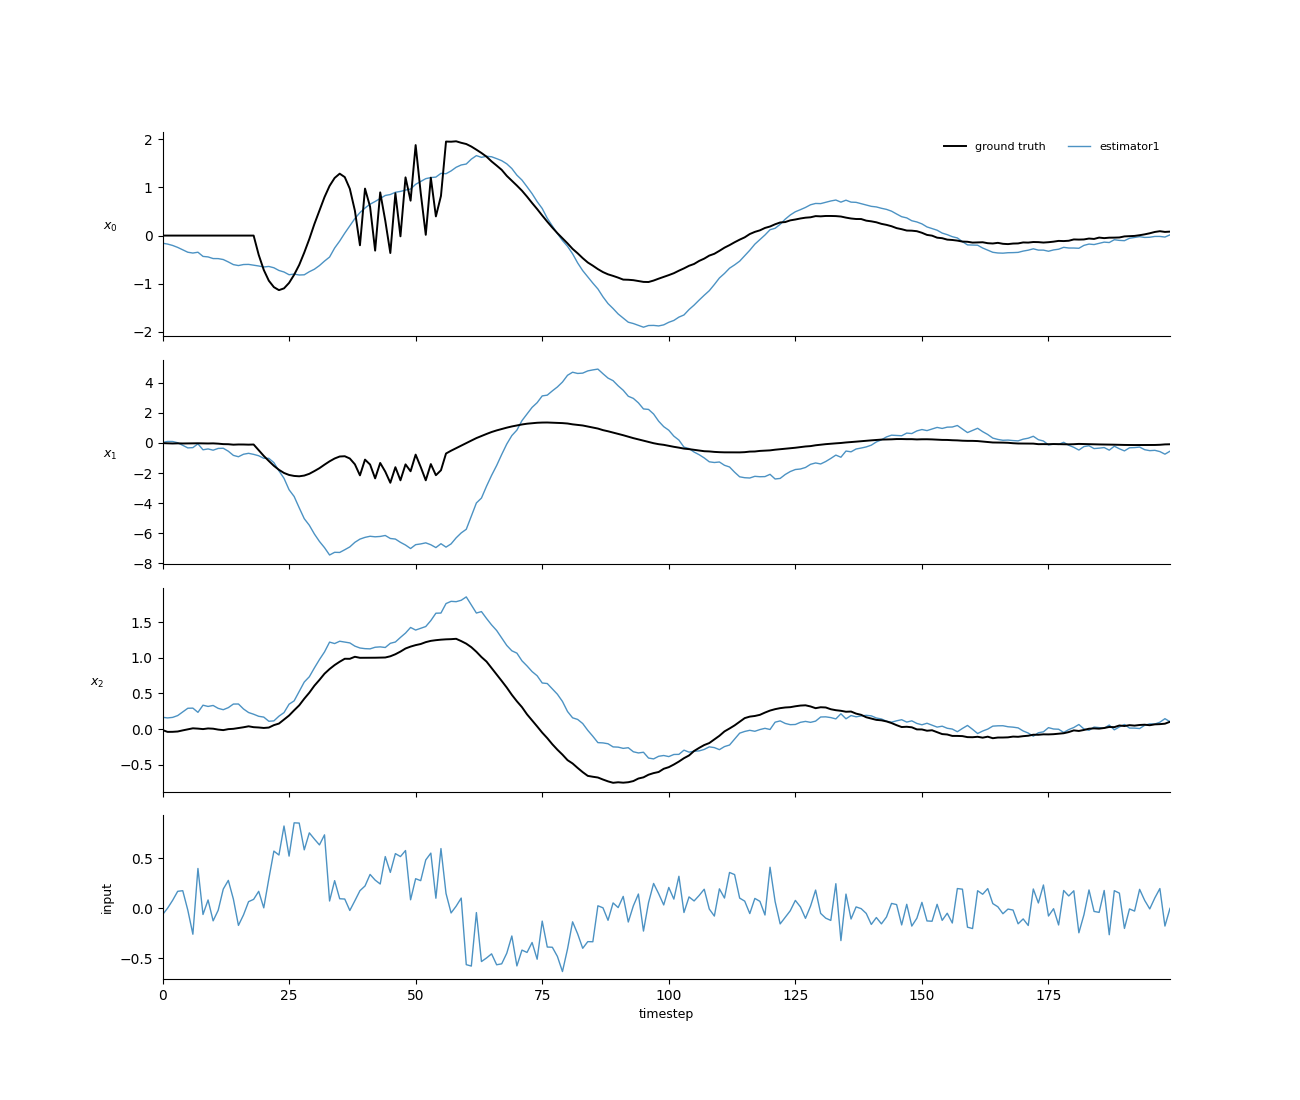

In [311]:
# try:
#     np.load("MethodResults/MinEnergyInput_Case2.npz")
# except FileNotFoundError:
#     results = run_functions_parallel(
#         functions,
#         observations,
#         latent_dim=3,
#         input_dim=1,
#         max_workers="auto",
#         native_threads_per_worker=1,
#         backend="thread",
#         print_shapes=False,
#     )
#     np.savez("MethodResults/MinEnergyInput_Case2.npz", **results)


latent_states, inputs = estimate_latent_and_input(observations, LatentDim=3, InputDim=1)
results = {
    "estimator1": {
        "latent_states": latent_states,
        "inputs": inputs,
    }
}


plot_input_latent_comparison_interactive(inputs, states, results, align_inputs=False, align_latents=True, active={})
plt.show()

### Case 3 - use non-normalty

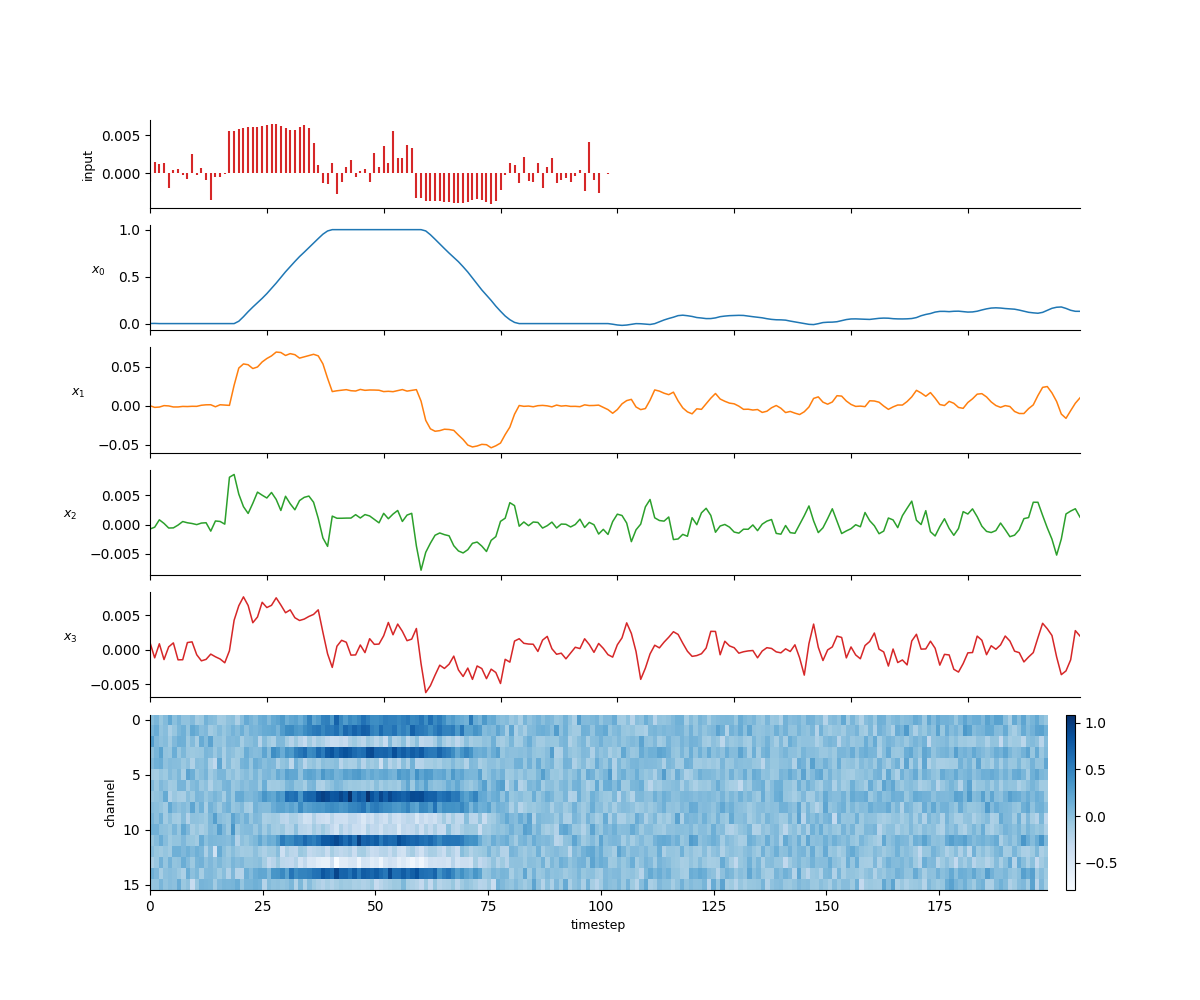

In [312]:
angle = 50 / 180 * np.pi
A = np.array([[0.98, 1, 0, 0],
              [0, 0.8, 3, 0],
              [0, 0, 0.75 * np.cos(angle), -0.75 * np.sin(angle)],
              [0, 0, 0.75 * np.sin(angle), 0.75 * np.cos(angle)],
])

B = np.array([[0.1], [0.1], [0.9], [0]])

C = np.random.normal(0, 1, (16, 4))
C[:, 0] += 0.2
C[:, 1] += 0.1
C /= np.linalg.norm(C, axis=1, keepdims=True)

waypoints = {}
for t in range(0, 20):
    waypoints[(t, 0)] = 0
for t in range(40, 60):
    waypoints[(t, 0)] = 1
for t in range(80, 100):
    waypoints[(t, 0)] = 0

x_noise = np.random.normal(0, 0.001, (200, 4))
y_noise = np.random.normal(0, 0.1, (200, 16))

states, observations, inputs, noiseless_states = simulate_from_latents(
    A, B, C,
    latents=waypoints,
    x_noise=x_noise,
    y_noise=y_noise,
    maxu=1.0,
)

plot_input_latent_observation(inputs, states, observations)
plt.show()

  EM iter   1  |  LL = -1967.3747  |  u_nnz = 194
  EM iter   2  |  LL = -2030.1037  |  u_nnz = 199
  EM iter   3  |  LL = -2075.1627  |  u_nnz = 199
  EM iter   4  |  LL = -2090.1497  |  u_nnz = 199
  EM iter   5  |  LL = -2093.6754  |  u_nnz = 198
  EM iter   6  |  LL = -2094.4255  |  u_nnz = 198
  EM iter   7  |  LL = -2094.5814  |  u_nnz = 198
  Converged at iter 7 (Δ=7.45e-05)


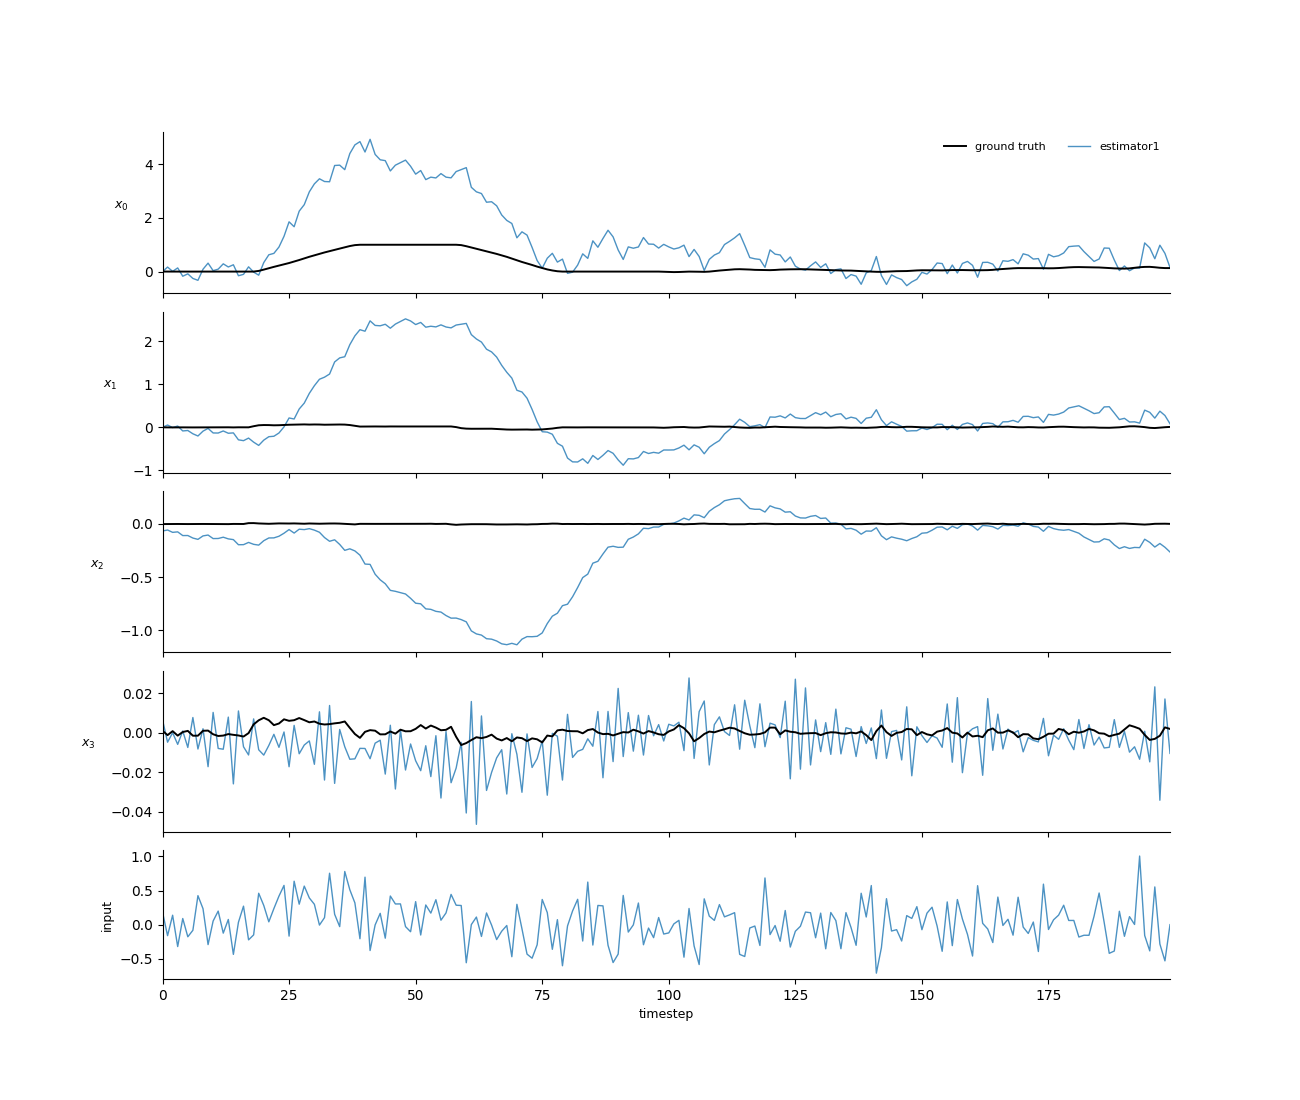

In [313]:
# try:
#     np.load("MethodResults/MinEnergyInput_Case3.npz")
# except FileNotFoundError:
#     results = run_functions_parallel(
#         functions,
#         observations,
#         latent_dim=4,
#         input_dim=1,
#         max_workers="auto",
#         native_threads_per_worker=1,
#         backend="thread",
#         print_shapes=False,
#     )
#     np.savez("MethodResults/MinEnergyInput_Case3.npz", **results)


latent_states, inputs = estimate_latent_and_input(observations, LatentDim=4, InputDim=1)
results = {
    "estimator1": {
        "latent_states": latent_states,
        "inputs": inputs,
    }
}



plot_input_latent_comparison_interactive(inputs, states, results, align_inputs=False, align_latents=True, active={})
plt.show()

### Case 4 - use non-normalty

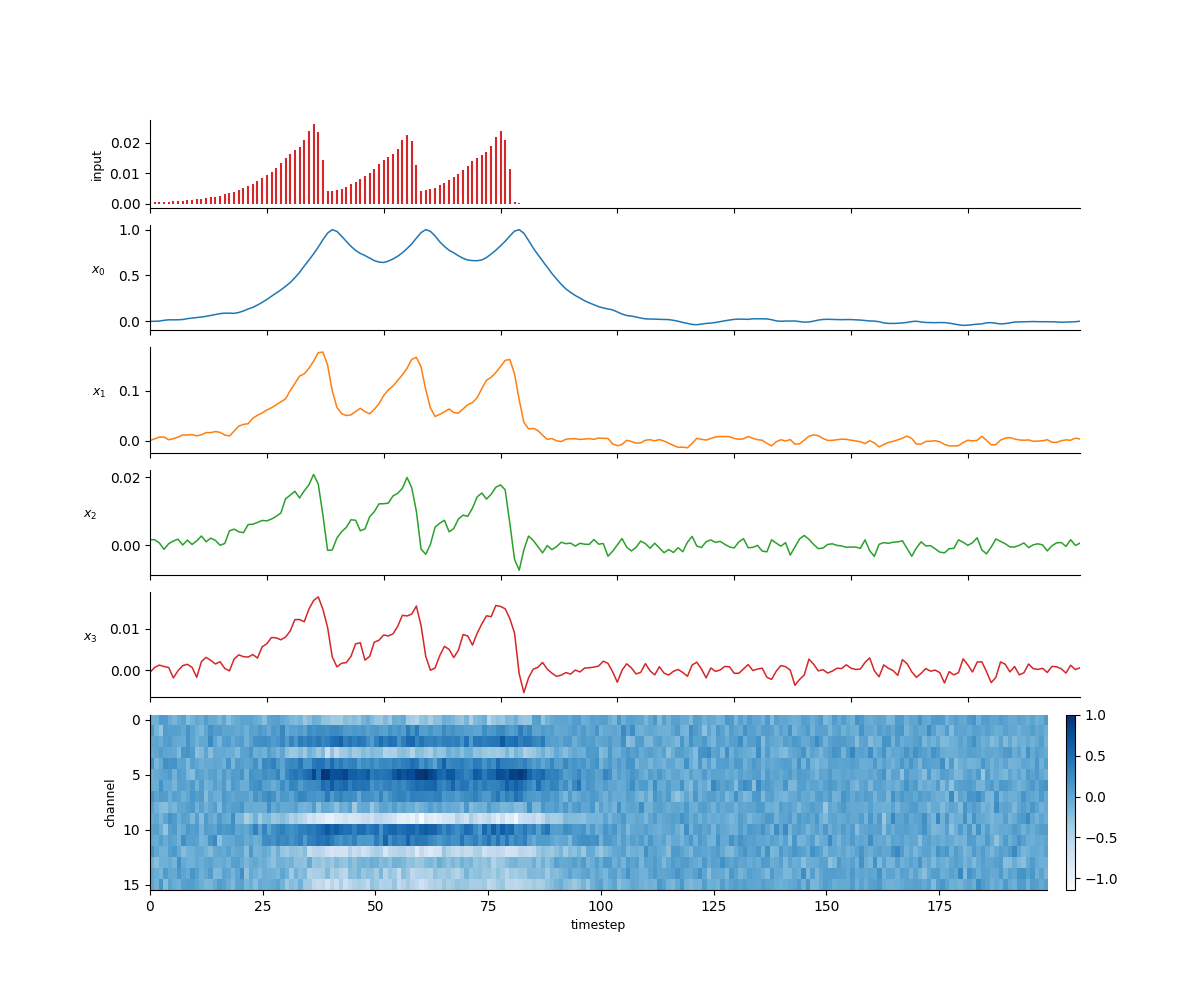

In [314]:
angle = 60 / 180 * np.pi
A = np.array([[0.88, 1, 0, 0],
              [0, 0.7, 3, 0],
              [0, 0, 0.65 * np.cos(angle), -0.65 * np.sin(angle)],
              [0, 0, 0.65 * np.sin(angle), 0.65 * np.cos(angle)],
])

B = np.array([[0.1], [0.1], [0.9], [0]])

C = np.random.normal(0, 1, (16, 4))
C[:, 0] += 0.2
C[:, 1] += 0.1
C /= np.linalg.norm(C, axis=1, keepdims=True)

waypoints = {
    (40, 0): 1,
    (60, 0): 1,
    (80, 0): 1,
}

x_noise = np.random.normal(0, 0.001, (200, 4))
y_noise = np.random.normal(0, 0.1, (200, 16))

states, observations, inputs, noiseless_states = simulate_from_latents(
    A, B, C,
    latents=waypoints,
    x_noise=x_noise,
    y_noise=y_noise,
    maxu=1.0,
)

plot_input_latent_observation(inputs, states, observations)
plt.show()

  EM iter   1  |  LL = -1981.2968  |  u_nnz = 195
  EM iter   2  |  LL = -2057.0558  |  u_nnz = 199
  EM iter   3  |  LL = -2106.6457  |  u_nnz = 197
  EM iter   4  |  LL = -2120.8643  |  u_nnz = 197
  EM iter   5  |  LL = -2123.7246  |  u_nnz = 197
  EM iter   6  |  LL = -2124.2504  |  u_nnz = 197
  EM iter   7  |  LL = -2124.3453  |  u_nnz = 198
  Converged at iter 7 (Δ=4.47e-05)


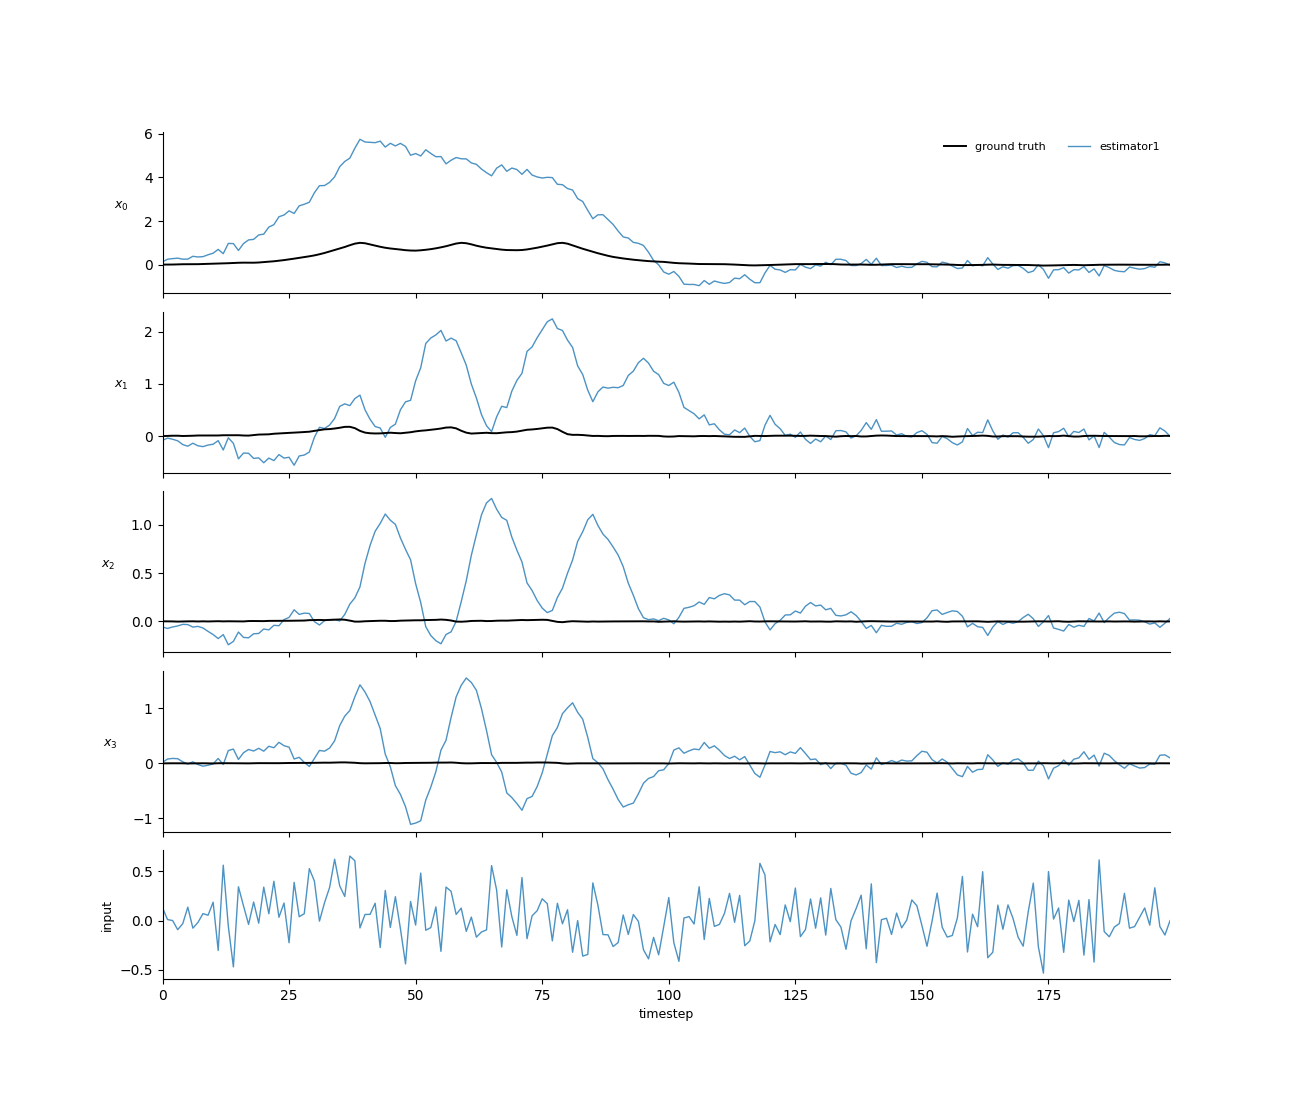

In [315]:
# try:
#     np.load("MethodResults/MinEnergyInput_Case4.npz")
# except FileNotFoundError:
#     results = run_functions_parallel(
#         functions,
#         observations,
#         latent_dim=4,
#         input_dim=1,
#         max_workers="auto",
#         native_threads_per_worker=1,
#         backend="thread",
#         print_shapes=False,
#     )
#     np.savez("MethodResults/MinEnergyInput_Case4.npz", **results)



latent_states, inputs = estimate_latent_and_input(observations, LatentDim=4, InputDim=1)
results = {
    "estimator1": {
        "latent_states": latent_states,
        "inputs": inputs,
    }
}

plot_input_latent_comparison_interactive(inputs, states, results, align_inputs=False, align_latents=True, active={})
plt.show()

## Hack Now Open